# Preliminaries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

## Data Loading

In [2]:
# =========================================================
# LOAD PREDICTIONS
# =========================================================

predictions = pd.read_csv("predictions/fdata/predictions_s.csv")

max_runtime = 259200
normalization = max_runtime / 100

errors_df = pd.DataFrame({
    "job_id": predictions["job_id"],
    "err_user": (predictions["pred_runtime_user"] - predictions["gt_runtime"]) / normalization,
    "err_heuristic": (predictions["pred_runtime_heuristic"] - predictions["gt_runtime"]) / normalization,
    "err_dt": (predictions["pred_runtime_dt"] - predictions["gt_runtime"]) / normalization,
    "err_rnp": (predictions["pred_runtime_rnp"] - predictions["gt_runtime"]) / normalization,
    "err_knn": (predictions["pred_runtime_knn"] - predictions["gt_runtime"]) / normalization,
    "err_llm": (predictions["pred_runtime_llm"] - predictions["gt_runtime"]) / normalization
})

## Helpers

In [3]:
def load_swf(filepath, sim_start_time):
    df = pd.read_csv(filepath, sep=';')

    # Convert timestamps to seconds from simulation start
    df["start_time"] = pd.to_datetime(df["start_time"]).astype("int64") // 10**9
    df["end_time"] = pd.to_datetime(df["end_time"]).astype("int64") // 10**9

    df["start_time"] -= sim_start_time
    df["end_time"] -= sim_start_time

    diff = min(df["start_time"])
    
    df["end_time"] -= diff
    df["start_time"] -= diff
    
    return df

In [4]:
def assign_job_classes(df, runtime_col="rtime", nodes_col="nodes"):

    df = df.copy()
    
    # --- Duration classification
    def duration_class(runtime):
        if 1 <= runtime < 900:
            return "Short"
        elif 900 <= runtime < 21600:
            return "Medium"
        elif 21600 <= runtime <= 259200:
            return "Long"
        else:
            return None

    # --- Size classification
    def size_class(nodes):
        if 1 <= nodes < 1024:
            return "Small"
        elif 1024 <= nodes < 4096:
            return "Medium"
        elif 4096 <= nodes <= 158976:
            return "Large"
        else:
            return None

    # Apply classifications
    df["size_class"] = df[nodes_col].apply(size_class)
    df["duration_class"] = df[runtime_col].apply(duration_class)

    return df

## Functions: Metrics

In [5]:
TOTAL_NODES = 158976

def compute_system_metrics(df, df_classes):
    df = df.copy()

    # -----------------------
    # 1. PREPROCESSING
    # -----------------------
    df['nodes'] = df['nodes'].astype(str).str.replace(r'^(\d+).*', r'\1', regex=True).astype(int)

    # Merge duration_class
    df = df.merge(df_classes[['job_id', 'duration_class']], on='job_id', how='left')

    # -----------------------
    # 2. UTILIZATION EVENTS
    # -----------------------
    metrics_events = []
    for _, row in df.iterrows():
        metrics_events.append((row["start_time"], row["nodes"]))
        metrics_events.append((row["end_time"], -row["nodes"]))

    metrics_df = pd.DataFrame(metrics_events, columns=['time', 'delta'])
    metrics_df = metrics_df.groupby('time')['delta'].sum().reset_index()
    metrics_df = metrics_df.sort_values('time')

    metrics_df['current_nodes'] = metrics_df['delta'].cumsum()
    metrics_df['utilization'] = metrics_df['current_nodes'] / TOTAL_NODES

    # -----------------------
    # 3. METRIC EVENTS (START ONLY)
    # -----------------------
    metric_events = df[['start_time', 'wtime', 'slowdown', 'duration_class']].copy()
    metric_events = metric_events.sort_values('start_time')

    # Aggregate per time
    base_agg = metric_events.groupby('start_time').agg({
        'wtime': 'sum',
        'slowdown': 'sum',
        'duration_class': 'count'
    }).rename(columns={'duration_class': 'job_count'})

    # Per-class counts (pivot)
    class_counts = (
        metric_events
        .groupby(['start_time', 'duration_class'])
        .size()
        .unstack(fill_value=0)
    )

    # Merge
    metric_events = base_agg.join(class_counts, how='left').fillna(0).reset_index()

    # -----------------------
    # 4. CUMULATIVE METRICS
    # -----------------------
    metric_events = metric_events.sort_values('start_time')

    # Total cumulative
    metric_events['cum_jobs'] = metric_events['job_count'].cumsum()
    metric_events['cum_wtime'] = metric_events['wtime'].cumsum()
    metric_events['cum_slowdown'] = metric_events['slowdown'].cumsum()

    metric_events['avg_wtime'] = metric_events['cum_wtime'] / metric_events['cum_jobs']
    metric_events['avg_slowdown'] = metric_events['cum_slowdown'] / metric_events['cum_jobs']

    # Per-class cumulative counts
    # duration_classes = ["Small-Short", "Small-Long", "Big-Short", "Big-Long"]
    duration_classes = ["Very-Short", "Short", "Medium", "Long", "Very-Long"]

    for cls in duration_classes:
        if cls not in metric_events.columns:
            metric_events[cls] = 0
        metric_events[f"cum_{cls}"] = metric_events[cls].cumsum()

    # -----------------------
    # 5. TIME SERIES ALIGNMENT
    # -----------------------
    metrics_df['time'] = metrics_df['time'].astype(int)
    metrics_df = metrics_df.set_index('time')

    metric_events['start_time'] = metric_events['start_time'].astype(int)
    metric_events = metric_events.set_index('start_time')

    t_min = min(metrics_df.index.min(), metric_events.index.min())
    t_max = max(metrics_df.index.max(), metric_events.index.max())
    full_range = np.arange(t_min, t_max + 1)

    # Reindex all series
    metrics_series = metrics_df['utilization'].reindex(full_range)
    wtime_series = metric_events['avg_wtime'].reindex(full_range)
    slowdown_series = metric_events['avg_slowdown'].reindex(full_range)
    jobs_series = metric_events['cum_jobs'].reindex(full_range)

    # Per-class series
    class_series = {
        cls: metric_events[f"cum_{cls}"].reindex(full_range)
        for cls in duration_classes
    }

    # Fill forward
    metrics_series = metrics_series.ffill().fillna(0)
    wtime_series = wtime_series.ffill().fillna(0)
    slowdown_series = slowdown_series.ffill().fillna(0)
    jobs_series = jobs_series.ffill().fillna(0)

    for cls in duration_classes:
        class_series[cls] = class_series[cls].ffill().fillna(0)

    # -----------------------
    # 6. OUTPUT
    # -----------------------
    result = {
        "time": full_range,
        "system_utilization": metrics_series.values,
        "average_utilization": metrics_series.mean(),
        "avg_waiting_time": wtime_series.values,
        "avg_slowdown": slowdown_series.values,
        "cum_jobs": jobs_series.values
    }

    # Add per-class outputs
    for cls in duration_classes:
        result[f"cum_jobs_{cls}"] = class_series[cls].values

    return result

In [6]:
def compute_ordering_metrics(
    df,
    predictions,
    pred_col="pred_runtime_llm",
    total_nodes=158976,
    saturation_threshold=0.90,
    short_jobs_threshold=900.0,
    n_bins=10,
    alpha=1.0,
    gamma=0.75,
):

    jobs = df.copy()

    jobs["nodes"] = (
        jobs["nodes"]
        .astype(str)
        .str.replace(r"^(\d+).*", r"\1", regex=True)
        .astype(int)
    )

    jobs = jobs.merge(
        predictions[["job_id", "gt_runtime", pred_col]],
        on="job_id",
        how="left",
    )

    jobs = jobs.rename(
        columns={
            "gt_runtime": "true_runtime",
            pred_col: "pred_runtime",
        }
    )

    # --------------------------------------------------
    # Duration classes
    # --------------------------------------------------
    def duration_class(runtime):
        if runtime < short_jobs_threshold:
            return "Short"
        elif runtime < 24 * short_jobs_threshold:
            return "Medium"
        else:
            return "Long"

    jobs["duration_class"] = jobs["true_runtime"].apply(duration_class)

    runtime_median = np.median(jobs["true_runtime"])
    total_runtime_mass = jobs["true_runtime"].sum()

    # --------------------------------------------------
    # Utilization curve
    # --------------------------------------------------
    util_events = []

    for _, row in jobs.iterrows():
        util_events.append((row["start_time"], row["nodes"]))
        util_events.append((row["end_time"], -row["nodes"]))

    util_df = pd.DataFrame(util_events, columns=["time", "delta"])

    util_df = (
        util_df.groupby("time")["delta"]
        .sum()
        .reset_index()
        .sort_values("time")
    )

    util_df["active_nodes"] = util_df["delta"].cumsum()
    util_df["util"] = util_df["active_nodes"] / total_nodes

    dispatch_times = np.sort(jobs["start_time"].unique())

    dispatch_df = pd.DataFrame({"time": dispatch_times})

    util_mapped = pd.merge_asof(
        dispatch_df,
        util_df[["time", "util"]],
        on="time",
        direction="backward",
    )

    util_mapping = (
        util_mapped.set_index("time")["util"].to_dict()
    )

    # --------------------------------------------------
    # Event accumulators
    # --------------------------------------------------
    ID_events = []

    ID_H_events = []
    ID_P_events = []

    ID_AWT_events = []
    ID_ASD_events = []

    QDS_AWT_events = []
    QDS_ASD_events = []

    # --------------------------------------------------
    # Main loop
    # --------------------------------------------------
    for t in dispatch_times:

        U_t = util_mapping.get(t, 0.0)

        if U_t < saturation_threshold:
            continue

        queue = jobs[
            (jobs["submit_time"] <= t)
            & (jobs["start_time"] > t)
        ].copy()

        n_t = len(queue)

        if n_t < 2:
            continue

        # --------------------------------------------------
        # Queue pressure P_t
        # --------------------------------------------------
        queue_runtime_mass = queue["true_runtime"].sum()

        P_t = np.log1p(n_t) * (
            1.0
            + queue_runtime_mass / total_runtime_mass
        )

        # --------------------------------------------------
        # Pairwise matrices
        # --------------------------------------------------
        arr = queue[
            ["true_runtime", "pred_runtime", "nodes"]
        ].to_numpy()

        r = arr[:, 0]
        p = arr[:, 1]
        nodes = arr[:, 2]

        r_i = r[:, np.newaxis]
        r_j = r[np.newaxis, :]

        p_i = p[:, np.newaxis]
        p_j = p[np.newaxis, :]

        nodes_j = nodes[np.newaxis, :]

        valid_pairs = r_i < r_j
        inversions = valid_pairs & (p_i > p_j)

        ID_t = 0.0
        ID_H_t = 0.0
        ID_P_t = 0.0
        ID_AWT_t = 0.0
        ID_ASD_t = 0.0

        if np.any(inversions):

            long_r = r_j
            short_r = r_i
            long_nodes = nodes_j

            # ------------------------------------------
            # Base inversion weight w(i,j,t)
            # ------------------------------------------
            runtime_gap = (
                (long_r - short_r)
                / long_r
            )

            size_weight = (
                long_nodes / total_nodes
            )

            duration_weight = (
                1.0
                + np.log1p(
                    long_r
                    / short_jobs_threshold
                )
            )

            w_matrix = (
                U_t
                * size_weight
                * duration_weight
                * runtime_gap
            )

            # ------------------------------------------
            # H_j
            # ------------------------------------------
            H_j = (
                np.maximum(
                    long_r / runtime_median,
                    1.0,
                )
            ) ** gamma

            # ------------------------------------------
            # S_i
            # ------------------------------------------
            S_i = (
                1.0
                / (
                    1.0
                    + np.log1p(
                        short_r
                        / short_jobs_threshold
                    )
                )
            )

            # ------------------------------------------
            # Ablation components
            # ------------------------------------------
            ID_t = float(
                np.sum(
                    w_matrix[inversions]
                )
            )

            ID_H_t = float(
                np.sum(
                    (
                        w_matrix
                        * H_j
                    )[inversions]
                )
            )

            ID_P_t = float(
                np.sum(
                    (
                        w_matrix
                        * P_t
                    )[inversions]
                )
            )

            ID_AWT_t = float(
                np.sum(
                    (
                        w_matrix
                        * H_j
                        * P_t
                    )[inversions]
                )
            )

            ID_ASD_t = float(
                np.sum(
                    (
                        w_matrix
                        * S_i
                    )[inversions]
                )
            )

        ID_events.append(ID_t)

        ID_H_events.append(ID_H_t)
        ID_P_events.append(ID_P_t)

        ID_AWT_events.append(ID_AWT_t)
        ID_ASD_events.append(ID_ASD_t)

        # --------------------------------------------------
        # Queue Distribution Scores
        # --------------------------------------------------
        queue = (
            queue
            .sort_values("pred_runtime")
            .reset_index(drop=True)
        )

        queue["bin"] = pd.cut(
            np.arange(len(queue)),
            bins=n_bins,
            labels=False,
            include_lowest=True,
        )

        QDS_AWT_t = 0.0
        QDS_ASD_t = 0.0

        for b in range(n_bins):

            bin_jobs = queue[
                queue["bin"] == b
            ]

            if len(bin_jobs) == 0:
                continue

            p_bin = b / (n_bins - 1)

            n_short = (
                bin_jobs["duration_class"]
                == "Short"
            ).sum()

            n_medium = (
                bin_jobs["duration_class"]
                == "Medium"
            ).sum()

            n_long = (
                bin_jobs["duration_class"]
                == "Long"
            ).sum()

            QDS_AWT_t += (
                n_short * p_bin
                + 0.5 * n_medium * p_bin
                + n_long * (1 - p_bin)
            )

            QDS_ASD_t += (
                3.0 * n_short * p_bin
            )

        QDS_AWT_events.append(
            U_t * QDS_AWT_t
        )

        QDS_ASD_events.append(
            U_t * QDS_ASD_t
        )

    # --------------------------------------------------
    # Reduction
    # --------------------------------------------------
    ID = np.sum(ID_events)

    ID_H = np.sum(ID_H_events)
    ID_P = np.sum(ID_P_events)

    ID_AWT = np.sum(ID_AWT_events)
    ID_ASD = np.sum(ID_ASD_events)

    QDS_AWT = (
        np.mean(QDS_AWT_events)
        if QDS_AWT_events
        else 0.0
    )

    QDS_ASD = (
        np.mean(QDS_ASD_events)
        if QDS_ASD_events
        else 0.0
    )

    OD_AWT = (
        ID_AWT
        * (1 + alpha * QDS_AWT)
    )

    OD_ASD = (
        ID_ASD
        * (1 + alpha * QDS_ASD)
    )

    return {

        # Ablation hierarchy
        "ID": ID,
        "ID_H": ID_H,
        "ID_P": ID_P,
        "ID_AWT": ID_AWT,
        "ID_ASD": ID_ASD,

        # Queue scores
        "QDS_AWT": QDS_AWT,
        "QDS_ASD": QDS_ASD,

        # Final metrics
        "OD_AWT": OD_AWT,
        "OD_ASD": OD_ASD,

        # Event traces (optional)
        "ID_events": np.array(ID_events),
        "ID_H_events": np.array(ID_H_events),
        "ID_P_events": np.array(ID_P_events),
        "ID_AWT_events": np.array(ID_AWT_events),
        "ID_ASD_events": np.array(ID_ASD_events),
    }

In [7]:
def count_jobs_in_window(err_df, t_start, t_end, methods=None):
    method_map = {
        "User": "user",
        "Actual": "actual",
        "Heuristic": "heuristic",
        "DT": "dt",
        "RNP": "rnp",
        "KNN": "knn",
        "LLM": "llm"
    }

    # duration_classes = ["Small-Short", "Small-Long", "Big-Short", "Big-Long"]
    duration_classes = ["Short", "Medium", "Long"]
    
    # Default: all methods
    if methods is None:
        methods = list(method_map.keys())

    results = {}

    for method in methods:
        suffix = method_map.get(method)
        st_col = f"st_{suffix}"

        if st_col not in err_df.columns:
            print(f"[WARNING] Column {st_col} not found, skipping {method}")
            continue

        counts = {}

        for cls in duration_classes:
            subset = err_df[err_df["duration_class"] == cls]

            mask = (subset[st_col] >= t_start) & (subset[st_col] <= t_end)
            counts[cls] = mask.sum()

        results[method] = counts

    # -----------------------
    # PRINT (nice format)
    # -----------------------
    print(f"\nTime window: [{t_start/60}, {t_end/60}]\n")

    for method, counts in results.items():
        total = sum(counts.values())
        print(f"{method}:")
        for cls in duration_classes:
            print(f"  {cls:12s}: {counts[cls]:4d}")
        print(f"  {'TOTAL':12s}: {total:4d}")
        print()

In [8]:
def print_utilization_in_window(data, start, end):
    """
    Filters and prints system_utilization based on a time range.
    """
    # Create a boolean mask where time is within the bounds
    time_array = data['time']
    mask = (time_array >= start) & (time_array <= end)
    
    # Apply the mask to the utilization array
    windowed_util = data['system_utilization'][mask]
    
    if windowed_util.size > 0:
        print(f"System Utilization from time {start} to {end}:")
        print(windowed_util)
    else:
        print(f"No data found for the time range: {start} to {end}")

## Plots

In [9]:
def plot_metrics(metrics_list, labels, title="System Utilization"):
    plt.figure(figsize=(12, 4))
    
    for sim_result, label in zip(metrics_list, labels):
        plt.plot(
            sim_result["time"],
            sim_result["system_utilization"],
            label=label
        )
    
    plt.xlabel("Time (seconds)")
    plt.ylabel("Utilization (0–1)")
    plt.title(title)
    
    plt.legend()
    plt.grid()
    plt.show()

def plot_metrics_window(metrics_list, labels, t_start=0, t_end=301, title="System Utilization", image_path=''):
    plt.figure(figsize=(12, 4))
    
    for sim_result, label in zip(metrics_list, labels):
        # Convert to numpy arrays for masking capability
        time = np.array(sim_result["time"])
        util = np.array(sim_result["system_utilization"]*100)
        
        # Create the mask: True if time is within our range
        mask = (time >= t_start) & (time <= t_end)
        
        # Apply the mask to both arrays
        plt.plot(time[mask], util[mask], label=label)
    
    ticks = np.arange(t_start, t_end, 300)
    plt.xlim(0, max(ticks))
    plt.xticks(ticks=ticks, labels=(ticks / 60).astype(int))
    plt.xlabel("Start Time (minutes)")
    plt.ylabel("Utilization (%)")
    plt.title(title)
    plt.legend()
    plt.grid(True)

    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")
    
    plt.show()


def plot_metrics_with_errors(
    metrics,
    err_df,
    labels,
    methods_to_plot=None,
    t_start=0,
    t_end=3900,
    highlight_window=None, # [w_start, w_end]
    title="Scheduling Metrics vs Errors",
    image_path=''
):

    # -----------------------
    # DEFAULTS
    # -----------------------
    if methods_to_plot is None:
        methods_to_plot = labels

    selected_indices = [i for i, l in enumerate(labels) if l in methods_to_plot]
    metrics = [metrics[i] for i in selected_indices]
    labels = [labels[i] for i in selected_indices]

    # -----------------------
    # FIGURE SETUP
    # -----------------------
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

    colors = plt.cm.tab10.colors

    # -----------------------
    # PLOT 1: AWT
    # -----------------------
    for i, (sim_result, label) in enumerate(zip(metrics, labels)):
        time = np.array(sim_result["time"])
        awt = np.array(sim_result["avg_waiting_time"])

        mask = (time >= t_start) & (time <= t_end)
        ax1.plot(time[mask], awt[mask], color=colors[i % len(colors)])

    ax1.set_ylabel("AWT")
    ax1.set_xlim(t_start, max(time[mask]) + 1)
    ax1.set_title(title)
    ax1.grid(True)

    # -----------------------
    # PLOT 2: ASD
    # -----------------------
    for i, (sim_result, label) in enumerate(zip(metrics, labels)):
        time = np.array(sim_result["time"])
        asd = np.array(sim_result["avg_slowdown"])

        mask = (time >= t_start) & (time <= t_end)
        ax2.plot(time[mask], asd[mask], color=colors[i % len(colors)])

    ax2.set_ylabel("ASD")
    ax2.set_xlim(t_start, max(time[mask]) + 1)
    ax2.grid(True)

    if highlight_window is not None:
        ax2.axvline(highlight_window[0], linestyle="--", alpha=0.5)
        ax2.axvline(highlight_window[1], linestyle="--", alpha=0.5)

    # -----------------------
    # PLOT 3: CUM JOBS + EVENTS
    # -----------------------

    class_markers = {
        "Short": "o",
        "Medium": "^",
        "Long": "s"
    }

    for i, (sim_result, label) in enumerate(zip(metrics, labels)):
        time = np.array(sim_result["time"])
        cum_jobs = np.array(sim_result["cum_jobs"])

        mask = (time >= t_start) & (time <= t_end)

        # Line: cumulative jobs
        ax3.plot(time[mask], cum_jobs[mask], color=colors[i % len(colors)])

        # Scatter: job start events (using err_df for timestamps)
        method_map = {
            "User": "user",
            "Actual": "actual",
            "Heuristic": "heuristic",
            "DT": "dt",
            "RNP": "rnp",
            "KNN": "knn",
            "LLM": "llm"
        }

        suffix = method_map[label]
        st_col = f"st_{suffix}"

        if st_col in err_df.columns:
            for duration_class, marker in class_markers.items():
                subset = err_df[err_df["duration_class"] == duration_class]

                x = subset[st_col]
                y = np.interp(x, time, cum_jobs)  # align with curve

                mask_scatter = (x >= t_start) & (x <= t_end)

                ax3.scatter(
                    x[mask_scatter],
                    y[mask_scatter],
                    color=colors[i % len(colors)],
                    marker=marker,
                    alpha=0.5,
                    s=20
                )

    ax3.set_ylabel("Jobs Started")
    ax3.set_xlim(t_start, max(time[mask]) + 1)
    ticks = np.arange(0, 20001, 2000)
    ax3.set_ylim(0, 20001)
    ax3.set_yticks(ticks)
    ax3.set_yticklabels((ticks).astype(int))
    ax3.grid(True)

    # -----------------------
    # PLOT 4: ERRORS
    # -----------------------
    method_map = {
        "User": "user",
        "Actual": "actual",
        "Heuristic": "heuristic",
        "DT": "dt",
        "RNP": "rnp",
        "KNN": "knn",
        "LLM": "llm"
    }

    for i, label in enumerate(labels):
        suffix = method_map[label]

        st_col = f"st_{suffix}"
        err_col = f"err_{suffix}"

        if st_col not in err_df.columns or err_col not in err_df.columns:
            continue

        for duration_class, marker in class_markers.items():
            subset = err_df[err_df["duration_class"] == duration_class]

            x = subset[st_col]
            y = subset[err_col]

            mask = (x >= t_start) & (x <= t_end)

            ax4.scatter(
                x[mask],
                y[mask],
                color=colors[i % len(colors)],
                marker=marker,
                alpha=0.6
            )

    ax4.set_ylabel("Normalized Error")
    ax4.axhline(0, linestyle="--")
    ticks = np.arange(t_start, t_end, 3600)
    ax4.set_xlim(t_start, max(ticks) + 1)
    ax4.set_xticks(ticks)
    ax4.set_xticklabels((ticks / 60).astype(int))
    ax4.set_xlabel("Start Time (minutes)")
    ax4.grid(True)

    # -----------------------
    # LEGEND
    # -----------------------
    method_handles = [
        plt.Line2D([0], [0], color=colors[i], lw=2, label=label)
        for i, label in enumerate(labels)
    ]

    class_handles = [
        plt.Line2D([0], [0], marker=marker, color='black', linestyle='None', label=cls)
        for cls, marker in class_markers.items()
    ]

    fig.legend(
        handles=method_handles + class_handles,
        loc="center left",
        bbox_to_anchor=(0.83, 0.5),
        borderaxespad=0,
        ncol=1
    )

    plt.tight_layout(rect=[0, 0, 0.90, 1])
    # -----------------------
    # SAVE / SHOW
    # -----------------------
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")

    plt.show()


def plot_starting_jobs_sizes_with_errors(
    metrics,
    err_df,
    labels,
    methods_to_plot=None,
    size_classes_to_plot=None,
    t_start=0,
    t_end=3900,
    error_window=(-100, 100),
    title="Starting Job Sizes vs Errors",
    image_path=''    
):

    # -----------------------
    # DEFAULTS
    # -----------------------
    if methods_to_plot is None:
        methods_to_plot = labels

    if size_classes_to_plot is None:
        size_classes_to_plot = ["Small", "Medium", "Large"]

    selected_indices = [i for i, l in enumerate(labels) if l in methods_to_plot]
    metrics = [metrics[i] for i in selected_indices]
    labels = [labels[i] for i in selected_indices]

    err_min, err_max = error_window

    # -----------------------
    # FIGURE SETUP
    # -----------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    colors = plt.cm.tab10.colors

    # --- MARKERS NOW BASED ON SIZE CLASS
    class_markers = {
        "Small": "o",
        "Medium": "^",
        "Large": "s"
    }
    
    method_map = {
        "User": "user",
        "Actual": "actual",
        "Heuristic": "heuristic",
        "DT": "dt",
        "RNP": "rnp",
        "KNN": "knn",
        "LLM": "llm"
    }

    # -----------------------
    # FILTER DATAFRAME ONCE
    # -----------------------
    err_df = err_df[err_df["size_class"].isin(size_classes_to_plot)]

    # -----------------------
    # PLOT 1: CUM JOBS + EVENTS
    # -----------------------
    for i, (sim_result, label) in enumerate(zip(metrics, labels)):
        time = np.array(sim_result["time"])
        cum_jobs = np.array(sim_result["cum_jobs"])

        mask = (time >= t_start) & (time <= t_end)

        # Line
        ax1.plot(time[mask], cum_jobs[mask], color=colors[i % len(colors)])

        suffix = method_map[label]
        st_col = f"st_{suffix}"
        err_col = f"err_{suffix}"

        if st_col in err_df.columns and err_col in err_df.columns:
            for size_class, marker in class_markers.items():

                if size_class not in size_classes_to_plot:
                    continue

                subset = err_df[err_df["size_class"] == size_class]

                x = subset[st_col]
                y = np.interp(x, time, cum_jobs)
                err = subset[err_col]

                mask_scatter = (
                    (x >= t_start) & (x <= t_end) &
                    (err >= err_min) & (err <= err_max)
                )

                ax1.scatter(
                    x[mask_scatter],
                    y[mask_scatter],
                    color=colors[i % len(colors)],
                    marker=marker,
                    alpha=0.5,
                    s=20
                )

    ax1.set_ylabel("Jobs Started")
    ax1.grid(True)

    # -----------------------
    # PLOT 2: ERRORS
    # -----------------------
    for i, label in enumerate(labels):
        suffix = method_map[label]

        st_col = f"st_{suffix}"
        err_col = f"err_{suffix}"

        if st_col not in err_df.columns or err_col not in err_df.columns:
            continue

        for size_class, marker in class_markers.items():

            if size_class not in size_classes_to_plot:
                continue

            subset = err_df[err_df["size_class"] == size_class]

            x = subset[st_col]
            y = subset[err_col]

            mask = (
                (x >= t_start) & (x <= t_end) &
                (y >= err_min) & (y <= err_max)
            )

            ax2.scatter(
                x[mask],
                y[mask],
                color=colors[i % len(colors)],
                marker=marker,
                alpha=0.6
            )

    ax2.set_ylabel("Normalized Error")
    ax2.axhline(0, linestyle="--")
    ax2.set_ylim(err_min, err_max)

    ticks = np.arange(t_start, t_end, 300)
    ax2.set_xlim(0, max(ticks) + 1)
    ax2.set_xticks(ticks)
    ax2.set_xticklabels((ticks / 60).astype(int))
    ax2.set_xlabel("Start Time (minutes)")
    ax2.grid(True)

    # -----------------------
    # LEGEND
    # -----------------------
    method_handles = [
        plt.Line2D([0], [0], color=colors[i], lw=2, label=label)
        for i, label in enumerate(labels)
    ]

    class_handles = [
        plt.Line2D([0], [0], marker=class_markers[cls],
                   color='black', linestyle='None', label=cls)
        for cls in size_classes_to_plot
    ]

    fig.legend(
        handles=method_handles + class_handles,
        loc="center left",
        bbox_to_anchor=(0.83, 0.5),
        borderaxespad=0,
        ncol=1
    )

    plt.tight_layout(rect=[0, 0, 0.90, 1])

    # -----------------------
    # SAVE / SHOW
    # -----------------------
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")

    plt.show()


def plot_job_errors_across_methods(
    metrics,
    err_df,
    labels,
    job_ids,
    methods_to_plot=None,
    t_start=0,
    t_end=3900,
    error_window=(-100, 100),
    utilization_window=(80, 100),
    title="Job-level Error Comparison",
    image_path=''
):

    # -----------------------
    # DEFAULTS
    # -----------------------
    if methods_to_plot is None:
        methods_to_plot = labels

    err_min, err_max = error_window
    util_min, util_max = utilization_window

    selected_indices = [i for i, l in enumerate(labels) if l in methods_to_plot]
    metrics = [metrics[i] for i in selected_indices]
    labels = [labels[i] for i in selected_indices]

    # -----------------------
    # FIGURE
    # -----------------------
    fig, (ax_util, ax_err) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    colors = plt.cm.tab10.colors

    method_color_map = {
        "User": colors[0],       # blue
        "Actual": colors[1],     # orange
        "Heuristic": colors[2],  # green
        "DT": colors[3],         # red
        "RNP": colors[4],        # purple
        "KNN": colors[5],        # brown
        "LLM": colors[6],        # pink
    }
        
    # Distinct markers for jobs
    marker_list = ['o', 's', '^', 'D', 'v', 'P', 'X', '*', '<', '>']

    if len(job_ids) > len(marker_list):
        raise ValueError(f"Too many job_ids ({len(job_ids)}). Max supported is {len(marker_list)}")

    job_marker_map = {job_id: marker_list[i] for i, job_id in enumerate(job_ids)}

    method_map = {
        "User": "user",
        "Actual": "actual",
        "Heuristic": "heuristic",
        "DT": "dt",
        "RNP": "rnp",
        "KNN": "knn",
        "LLM": "llm"
    }

    df_subset = err_df[err_df["job_id"].isin(job_ids)]

    # -----------------------
    # PLOT 1: SYSTEM UTILIZATION
    # -----------------------
    for i, (sim_result, label) in enumerate(zip(metrics, labels)):
        time = np.array(sim_result["time"])
        util = np.array(sim_result["system_utilization"]) * 100

        mask = (time >= t_start) & (time <= t_end)

        ax_util.plot(
            time[mask],
            util[mask],
            color=method_color_map[label]
        )

    ax_util.set_ylabel("Utilization (%)")
    ax_util.set_ylim(util_min, util_max)
    ax_util.grid(True)

    # -----------------------
    # PLOT 2: ERRORS
    # -----------------------
    for i, label in enumerate(labels):
        suffix = method_map[label]

        st_col = f"st_{suffix}"
        err_col = f"err_{suffix}"

        if st_col not in df_subset.columns or err_col not in df_subset.columns:
            continue

        for job_id in job_ids:
            job_data = df_subset[df_subset["job_id"] == job_id]

            x = job_data[st_col]
            y = job_data[err_col]

            mask = (
                (x >= t_start) & (x <= t_end) &
                (y >= err_min) & (y <= err_max)
            )

            ax_err.scatter(
                x[mask],
                y[mask],
                color=method_color_map[label],
                marker=job_marker_map[job_id],
                s=80,
                alpha=0.8
            )

    ax_err.set_ylabel("Normalized Error")
    ax_err.axhline(0, linestyle="--")
    ax_err.set_ylim(err_min, err_max)

    # X-axis formatting (minutes)
    ticks = np.arange(t_start, t_end, 300)
    ax_err.set_xlim(0, max(ticks) + 1)
    ax_err.set_xticks(ticks)
    ax_err.set_xticklabels((ticks / 60).astype(int))
    ax_err.set_xlabel("Start Time (minutes)")
    ax_err.grid(True)

    ax_util.set_title(title)

    # -----------------------
    # LEGEND
    # -----------------------
    method_handles = [
        plt.Line2D([0], [0], color=method_color_map[label], lw=2, label=label)
        for i, label in enumerate(labels)
    ]

    job_handles = [
        plt.Line2D([0], [0], marker=job_marker_map[j], color='black',
                   linestyle='None', markersize=8, label=f"Job {j}")
        for j in job_ids
    ]

    fig.legend(
        handles=method_handles + job_handles,
        loc="center left",
        bbox_to_anchor=(0.83, 0.5),
        borderaxespad=0,
        ncol=1
    )

    plt.tight_layout(rect=[0, 0, 0.90, 1])
    # -----------------------
    # SAVE / SHOW
    # -----------------------
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")

    plt.show()

In [10]:
def plot_job_class_matrix_differences(
    err_df,
    t_start,
    t_end,
    image_path=''
):

    method_map = {
        "User": "user",
        "Actual": "actual",
        "Heuristic": "heuristic",
        "DT": "dt",
        "RNP": "rnp",
        "KNN": "knn",
        "LLM": "llm"
    }

    methods = [m for m in method_map.keys() if m != "Actual"]

    x_classes = ["Small", "Medium", "Large"]
    y_classes = ["Short", "Medium", "Long"]
    
    # -----------------------
    # HELPER
    # -----------------------
    def build_matrix(df, st_col):
        mask = (df[st_col] >= t_start) & (df[st_col] <= t_end)
        sub = df[mask]

        return (
            sub.groupby(["duration_class", "size_class"])
            .size()
            .unstack(fill_value=0)
            .reindex(index=y_classes, columns=x_classes, fill_value=0)
        )

    # -----------------------
    # BASELINE (Actual)
    # -----------------------
    actual_col = f"st_{method_map['Actual']}"
    actual_matrix = build_matrix(err_df, actual_col)

    diff_matrices = {}
    vmax = 0

    for method in methods:
        st_col = f"st_{method_map[method]}"
        if st_col not in err_df.columns:
            continue

        diff = build_matrix(err_df, st_col) - actual_matrix
        diff_matrices[method] = diff
        vmax = max(vmax, np.abs(diff.values).max())

    # -----------------------
    # PLOT
    # -----------------------
    fig, axes = plt.subplots(
        2, 3,
        figsize=(9, 6),
        sharex=True,
        sharey=True,
        constrained_layout=True   # ✅ KEY FIX
    )

    axes = axes.flatten()

    im = None

    for ax, (method, diff) in zip(axes, diff_matrices.items()):

        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
        
        im = ax.imshow(diff.values, cmap="coolwarm", norm=norm)

        ax.set_title(method, fontsize=11)

        ax.set_xticks(np.arange(len(x_classes)))
        ax.set_yticks(np.arange(len(y_classes)))

        ax.set_xticklabels(x_classes, rotation=45, ha="right", fontsize=9)
        ax.set_yticklabels(y_classes, fontsize=9)

        # Force labels to be shown on ALL subplots
        ax.tick_params(axis='x', labelbottom=True)
        ax.tick_params(axis='y', labelleft=True)

        # annotate
        for i in range(len(y_classes)):
            for j in range(len(x_classes)):
                val = diff.values[i, j]
        
                # normalize value for color intensity
                norm_val = abs(val) / vmax if vmax > 0 else 0
        
                text_color = "white" if norm_val > 0.5 else "black"
        
                ax.text(j, i, f"{val:+d}",
                        ha="center", va="center",
                        fontsize=10,
                        color=text_color)

    # -----------------------
    # COLORBAR (outside grid)
    # -----------------------
    cbar = fig.colorbar(
        im,
        ax=axes,
        location="right",
        shrink=0.85,
        pad=0.02   # ✅ spacing from plots
    )
    # cbar.set_label("Δ #Jobs (Method - Actual)")

    # -----------------------
    # GLOBAL TITLE
    # -----------------------
    fig.suptitle(
        f"Time Window B: [{t_start}, {t_end}] s",
        # f"Job Count Per Duration/Size Class (Δ vs Actual)\nTime Window: [{t_start}, {t_end}] s",
        fontsize=14
    )

    fig.supxlabel("Size", fontsize=12)
    fig.supylabel("Duration", fontsize=12)

    # -----------------------
    # SAVE / SHOW
    # -----------------------
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")
    
    plt.show()


def plot_duration_vs_methods_differences_multi(
    err_df,
    t_windows,   # [[t_start, t_end], ...]
    image_path=''
):

    if len(t_windows) > 8:
        raise ValueError("Maximum supported windows is 8")

    method_map = {
        "User": "user",
        "Actual": "actual",
        "Heuristic": "heuristic",
        "DT": "dt",
        "RNP": "rnp",
        "KNN": "knn",
        "LLM": "llm"
    }

    window_map = {
        0: "A",
        1: "B",
        2: "C",
        3: "D",
        4: "E",
        5: "F",
        6: "G",
        7: "H"
    }

    methods = [m for m in method_map.keys() if m != "Actual"]
    duration_classes = ["Short", "Medium", "Long"]

    # -----------------------
    # HELPER
    # -----------------------
    def count_by_duration(df, st_col, t_start, t_end):
        mask = (df[st_col] >= t_start) & (df[st_col] <= t_end)
        sub = df[mask]

        return (
            sub.groupby("duration_class")
            .size()
            .reindex(duration_classes, fill_value=0)
        )

    # -----------------------
    # COMPUTE ALL MATRICES FIRST
    # -----------------------
    all_diff_matrices = []
    vmax = 0

    actual_col = f"st_{method_map['Actual']}"
    if actual_col not in err_df.columns:
        raise ValueError(f"{actual_col} not found")

    for (t_start, t_end) in t_windows:

        actual_counts = count_by_duration(err_df, actual_col, t_start, t_end)

        diff_matrix = pd.DataFrame(index=duration_classes, columns=methods)

        for method in methods:
            st_col = f"st_{method_map[method]}"
            if st_col not in err_df.columns:
                continue

            counts = count_by_duration(err_df, st_col, t_start, t_end)
            diff = counts - actual_counts

            diff_matrix[method] = diff

        diff_matrix = diff_matrix.fillna(0)

        vmax = max(vmax, np.abs(diff_matrix.values).max())
        all_diff_matrices.append(diff_matrix)

    # -----------------------
    # PLOT GRID
    # -----------------------
    n_plots = len(t_windows)
    n_cols = 3
    n_rows = 2

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 3 * n_rows),
        sharex=True,
        sharey=True,
        constrained_layout=True
    )

    # Normalize axes array
    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    im = None

    # -----------------------
    # DRAW EACH SUBPLOT
    # -----------------------
    for idx, ((t_start, t_end), diff_matrix) in enumerate(zip(t_windows, all_diff_matrices)):
        ax = axes[idx]

        im = ax.imshow(diff_matrix.values, cmap="coolwarm", norm=norm)

        ax.set_title(f"Time Window {window_map[idx]}: [{t_start}, {t_end}] s", fontsize=10)

        ax.set_xticks(np.arange(len(methods)))
        ax.set_yticks(np.arange(len(duration_classes)))

        ax.set_xticklabels(methods, rotation=45, ha="right", fontsize=8)
        ax.set_yticklabels(duration_classes, fontsize=8)
        
        # Force labels to be shown on ALL subplots
        ax.tick_params(axis='x', labelbottom=True)
        ax.tick_params(axis='y', labelleft=True)

        # annotate
        for i in range(len(duration_classes)):
            for j in range(len(methods)):
                val = int(diff_matrix.iloc[i, j])

                norm_val = abs(val) / vmax if vmax > 0 else 0
                text_color = "white" if norm_val > 0.5 else "black"

                ax.text(j, i, f"{val:+d}",
                        ha="center", va="center",
                        fontsize=10,
                        color=text_color)

    # Hide unused axes
    for j in range(idx + 1, len(axes)):
        axes[j].axis("off")

    # -----------------------
    # SHARED LABELS
    # -----------------------
    fig.supxlabel("Method", fontsize=12)
    fig.supylabel("Duration", fontsize=12)
        
    # -----------------------
    # SINGLE COLORBAR (RIGHT SIDE)
    # -----------------------
    cbar = fig.colorbar(
        im,
        ax=axes[:n_plots],
        location="right",
        shrink=0.85,
        pad=0.02
    )
    # cbar.set_label("Δ #Jobs (Method - Actual)")

    fig.suptitle("Job Count Per Duration Class (Δ vs Actual)", fontsize=14)

    # -----------------------
    # SAVE / SHOW
    # -----------------------
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")

    plt.show()

In [11]:
workload_column_names = [
    "Job Number", "Submit Time", "Wait Time", "Run Time",
    "Number of Allocated Nodes", "Average CPU Time Used",
    "Used Memory", "Requested Number of Nodes",
    "Requested Time", "Requested Memory", "Status",
    "User ID", "Group ID", "Executable Number",
    "Queue Number", "Partition Number",
    "Preceding Job Number", "Think Time from Preceding Job"
]

column_names = ['n', 'job_id', 'submit_time', 'start_time', 'end_time', 'wtime', 'rtime', 'slowdown', 'nodes']

sim_start_time = 1600210177

# Heavy 1

## System Metrics Computation

In [12]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/fdata/fdata_18k_1.swf',
    header=None,
    sep='\t'
)
workload_df.columns = workload_column_names
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})


# =========================================================
# ACTUAL
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_1/fdata_18k_1_SJF_Oracle.swf'
exec_df = load_swf(filepath, sim_start_time)

df_oracle = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_oracle = df_oracle.sort_values("start_time").reset_index(drop=True)
df_oracle = df_oracle[column_names]

err_df_actual = df_oracle.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_actual = assign_job_classes(err_df_actual)
err_df_actual = err_df_actual.rename(columns={"start_time": "st_actual"})
err_df_actual["err_actual"] = 0
err_df_actual = err_df_actual[["job_id", "duration_class", "size_class", "st_actual", "err_actual"]]

metrics_actual = compute_system_metrics(df_oracle, err_df_actual)

# sa_metrics_actual = compute_ordering_metrics(df_oracle, predictions, pred_col="gt_runtime")


# =========================================================
# USER
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_1/fdata_18k_1_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

df_user = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_user = df_user.sort_values("start_time").reset_index(drop=True)
df_user = df_user[column_names]

err_df_user = df_user.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_user = assign_job_classes(err_df_user)
err_df_user = err_df_user.rename(columns={"start_time": "st_user"})
err_df_user = err_df_user[["job_id", "duration_class", "size_class", "st_user", "err_user"]]

metrics_user = compute_system_metrics(df_user, err_df_user)

sa_metrics_user = compute_ordering_metrics(df_user, predictions, pred_col="pred_runtime_user")


# =========================================================
# HEURISTIC
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_1/fdata_18k_1_SJF_H.swf'
exec_df = load_swf(filepath, sim_start_time)

df_heuristic = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_heuristic = df_heuristic.sort_values("start_time").reset_index(drop=True)
df_heuristic = df_heuristic[column_names]

err_df_heuristic = df_heuristic.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_heuristic = assign_job_classes(err_df_heuristic)
err_df_heuristic = err_df_heuristic.rename(columns={"start_time": "st_heuristic"})
err_df_heuristic = err_df_heuristic[["job_id", "duration_class", "size_class", "st_heuristic", "err_heuristic"]]

metrics_heuristic = compute_system_metrics(df_heuristic, err_df_heuristic)

sa_metrics_heuristic = compute_ordering_metrics(df_heuristic, predictions, pred_col="pred_runtime_heuristic")


# =========================================================
# DT
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_1/fdata_18k_1_SJF_DT.swf'
exec_df = load_swf(filepath, sim_start_time)


df_dt = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_dt = df_dt.sort_values("start_time").reset_index(drop=True)
df_dt = df_dt[column_names]

err_df_dt = df_dt.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_dt = assign_job_classes(err_df_dt)
err_df_dt = err_df_dt.rename(columns={"start_time": "st_dt"})
err_df_dt = err_df_dt[["job_id", "duration_class", "size_class", "st_dt", "err_dt"]]

metrics_dt = compute_system_metrics(df_dt, err_df_dt)

sa_metrics_dt = compute_ordering_metrics(df_dt, predictions, pred_col="pred_runtime_dt")


# =========================================================
# RNP
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_1/fdata_18k_1_SJF_RNP.swf'
exec_df = load_swf(filepath, sim_start_time)

df_rnp = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_rnp = df_rnp.sort_values("start_time").reset_index(drop=True)
df_rnp = df_rnp[column_names]

err_df_rnp = df_rnp.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_rnp = assign_job_classes(err_df_rnp)
err_df_rnp = err_df_rnp.rename(columns={"start_time": "st_rnp"})
err_df_rnp = err_df_rnp[["job_id", "duration_class", "size_class", "st_rnp", "err_rnp"]]

metrics_rnp = compute_system_metrics(df_rnp, err_df_rnp)

sa_metrics_rnp = compute_ordering_metrics(df_rnp, predictions, pred_col="pred_runtime_rnp")


# =========================================================
# KNN
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_1/fdata_18k_1_SJF_KNN.swf'
exec_df = load_swf(filepath, sim_start_time)

df_knn = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_knn = df_knn.sort_values("start_time").reset_index(drop=True)
df_knn = df_knn[column_names]

err_df_knn = df_knn.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_knn = assign_job_classes(err_df_knn)
err_df_knn = err_df_knn.rename(columns={"start_time": "st_knn"})
err_df_knn = err_df_knn[["job_id", "duration_class", "size_class", "st_knn", "err_knn"]]

metrics_knn = compute_system_metrics(df_knn, err_df_knn)

sa_metrics_knn = compute_ordering_metrics(df_knn, predictions, pred_col="pred_runtime_knn")


# =========================================================
# LLM
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_1/fdata_18k_1_SJF_LLM.swf'
exec_df = load_swf(filepath, sim_start_time)

df_llm = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_llm = df_llm.sort_values("start_time").reset_index(drop=True)
df_llm = df_llm[column_names]

err_df_llm = df_llm.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_llm = assign_job_classes(err_df_llm)
err_df_llm = err_df_llm.rename(columns={"start_time": "st_llm"})
err_df_llm = err_df_llm[["job_id", "duration_class", "size_class", "st_llm", "err_llm"]]

metrics_llm = compute_system_metrics(df_llm, err_df_llm)

sa_metrics_llm = compute_ordering_metrics(df_llm, predictions, pred_col="pred_runtime_llm")

In [13]:
print(f'"ID": [{sa_metrics_user["ID"]}, 0, {sa_metrics_heuristic["ID"]}, {sa_metrics_dt["ID"]}, {sa_metrics_rnp["ID"]}, {sa_metrics_knn["ID"]}, {sa_metrics_llm["ID"]}],')
print(f'"ID_H": [{sa_metrics_user["ID_H"]}, 0, {sa_metrics_heuristic["ID_H"]}, {sa_metrics_dt["ID_H"]}, {sa_metrics_rnp["ID_H"]}, {sa_metrics_knn["ID_H"]}, {sa_metrics_llm["ID_H"]}],')
print(f'"ID_P": [{sa_metrics_user["ID_P"]}, 0, {sa_metrics_heuristic["ID_P"]}, {sa_metrics_dt["ID_P"]}, {sa_metrics_rnp["ID_P"]}, {sa_metrics_knn["ID_P"]}, {sa_metrics_llm["ID_P"]}],')
print(f'"ID_AWT": [{sa_metrics_user["ID_AWT"]}, 0, {sa_metrics_heuristic["ID_AWT"]}, {sa_metrics_dt["ID_AWT"]}, {sa_metrics_rnp["ID_AWT"]}, {sa_metrics_knn["ID_AWT"]}, {sa_metrics_llm["ID_AWT"]}],')
print(f'"ID_ASD": [{sa_metrics_user["ID_ASD"]}, 0, {sa_metrics_heuristic["ID_ASD"]}, {sa_metrics_dt["ID_ASD"]}, {sa_metrics_rnp["ID_ASD"]}, {sa_metrics_knn["ID_ASD"]}, {sa_metrics_llm["ID_ASD"]}],')
print(f'"QDS_AWT": [{sa_metrics_user["QDS_AWT"]}, 0, {sa_metrics_heuristic["QDS_AWT"]}, {sa_metrics_dt["QDS_AWT"]}, {sa_metrics_rnp["QDS_AWT"]}, {sa_metrics_knn["QDS_AWT"]}, {sa_metrics_llm["QDS_AWT"]}],') 
print(f'"QDS_ASD": [{sa_metrics_user["QDS_ASD"]}, 0, {sa_metrics_heuristic["QDS_ASD"]}, {sa_metrics_dt["QDS_ASD"]}, {sa_metrics_rnp["QDS_ASD"]}, {sa_metrics_knn["QDS_ASD"]}, {sa_metrics_llm["QDS_ASD"]}],')
print(f'"OD_AWT": [{sa_metrics_user["OD_AWT"]}, 0, {sa_metrics_heuristic["OD_AWT"]}, {sa_metrics_dt["OD_AWT"]}, {sa_metrics_rnp["OD_AWT"]}, {sa_metrics_knn["OD_AWT"]}, {sa_metrics_llm["OD_AWT"]}],') 
print(f'"OD_ASD": [{sa_metrics_user["OD_ASD"]}, 0, {sa_metrics_heuristic["OD_ASD"]}, {sa_metrics_dt["OD_ASD"]}, {sa_metrics_rnp["OD_ASD"]}, {sa_metrics_knn["OD_ASD"]}, {sa_metrics_llm["OD_ASD"]}]')

"ID": [4285719.865245825, 0, 4540166.691992608, 5370743.714357964, 6683661.249775931, 2691150.6641872637, 1098111.716212449],
"ID_H": [13096053.772707932, 0, 14261512.147071382, 23904045.198112324, 24071934.31515471, 10418465.113217726, 3161346.000683481],
"ID_P": [67078654.907227844, 0, 71964402.11360256, 85766281.78922702, 107952631.48931381, 42842739.192744136, 16946969.07272175],
"ID_AWT": [200650058.6612031, 0, 222388702.70052177, 380514306.1635782, 390043573.01189595, 164566226.0103142, 47837563.354174145],
"ID_ASD": [2683031.057756298, 0, 2632164.56262636, 2319302.9943053797, 4220420.8382853065, 1434167.447651761, 570717.6861325346],
"QDS_AWT": [1409.4364194153864, 0, 1327.373059941865, 1448.5140839698893, 1629.9730081277864, 1250.859007882153, 1052.3859088097101],
"QDS_ASD": [804.8702113164295, 0, 736.5203244682393, 373.67552242557986, 812.3270220913445, 348.14878887890626, 173.09745083771537],
"OD_AWT": [283004150293.5945, 0, 295415161502.7938, 551560845936.1371, 636150539576.

## Merge metrics and errors

In [17]:
metrics = [
    metrics_user,
    metrics_actual,
    metrics_heuristic,
    metrics_dt,
    metrics_rnp,
    metrics_knn,
    metrics_llm
]

labels = [
    "User",
    "Actual",
    "Heuristic",
    "DT",
    "RNP",
    "KNN",
    "LLM"
]

In [18]:
err_df = err_df_user.merge(
            err_df_actual[["job_id", "st_actual", "err_actual"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_heuristic[["job_id", "st_heuristic", "err_heuristic"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_dt[["job_id", "st_dt", "err_dt"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_rnp[["job_id", "st_rnp", "err_rnp"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_knn[["job_id", "st_knn", "err_knn"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_llm[["job_id", "st_llm", "err_llm"]],
            on="job_id",
            how="left"
)

## Plots

### System Utilization

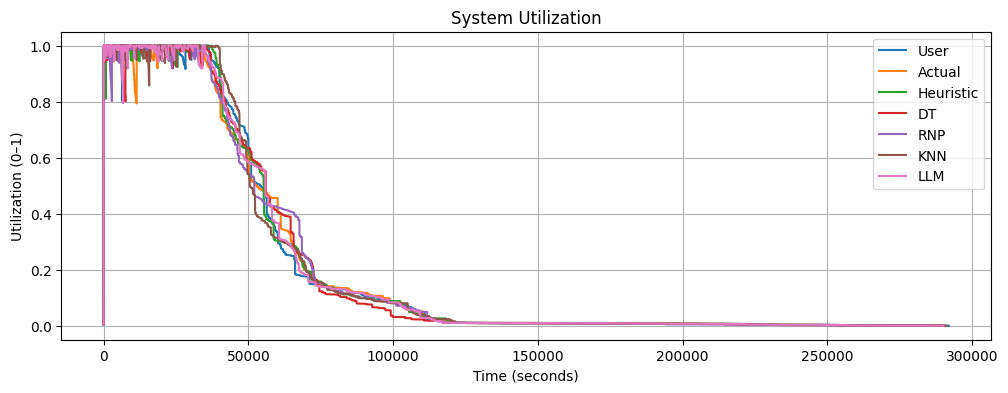

In [14]:
plot_metrics(metrics, labels)

### System Metrics vs Prediction Error

Grafico salvato in: images/18000x158976/metrics_vs_errors.png


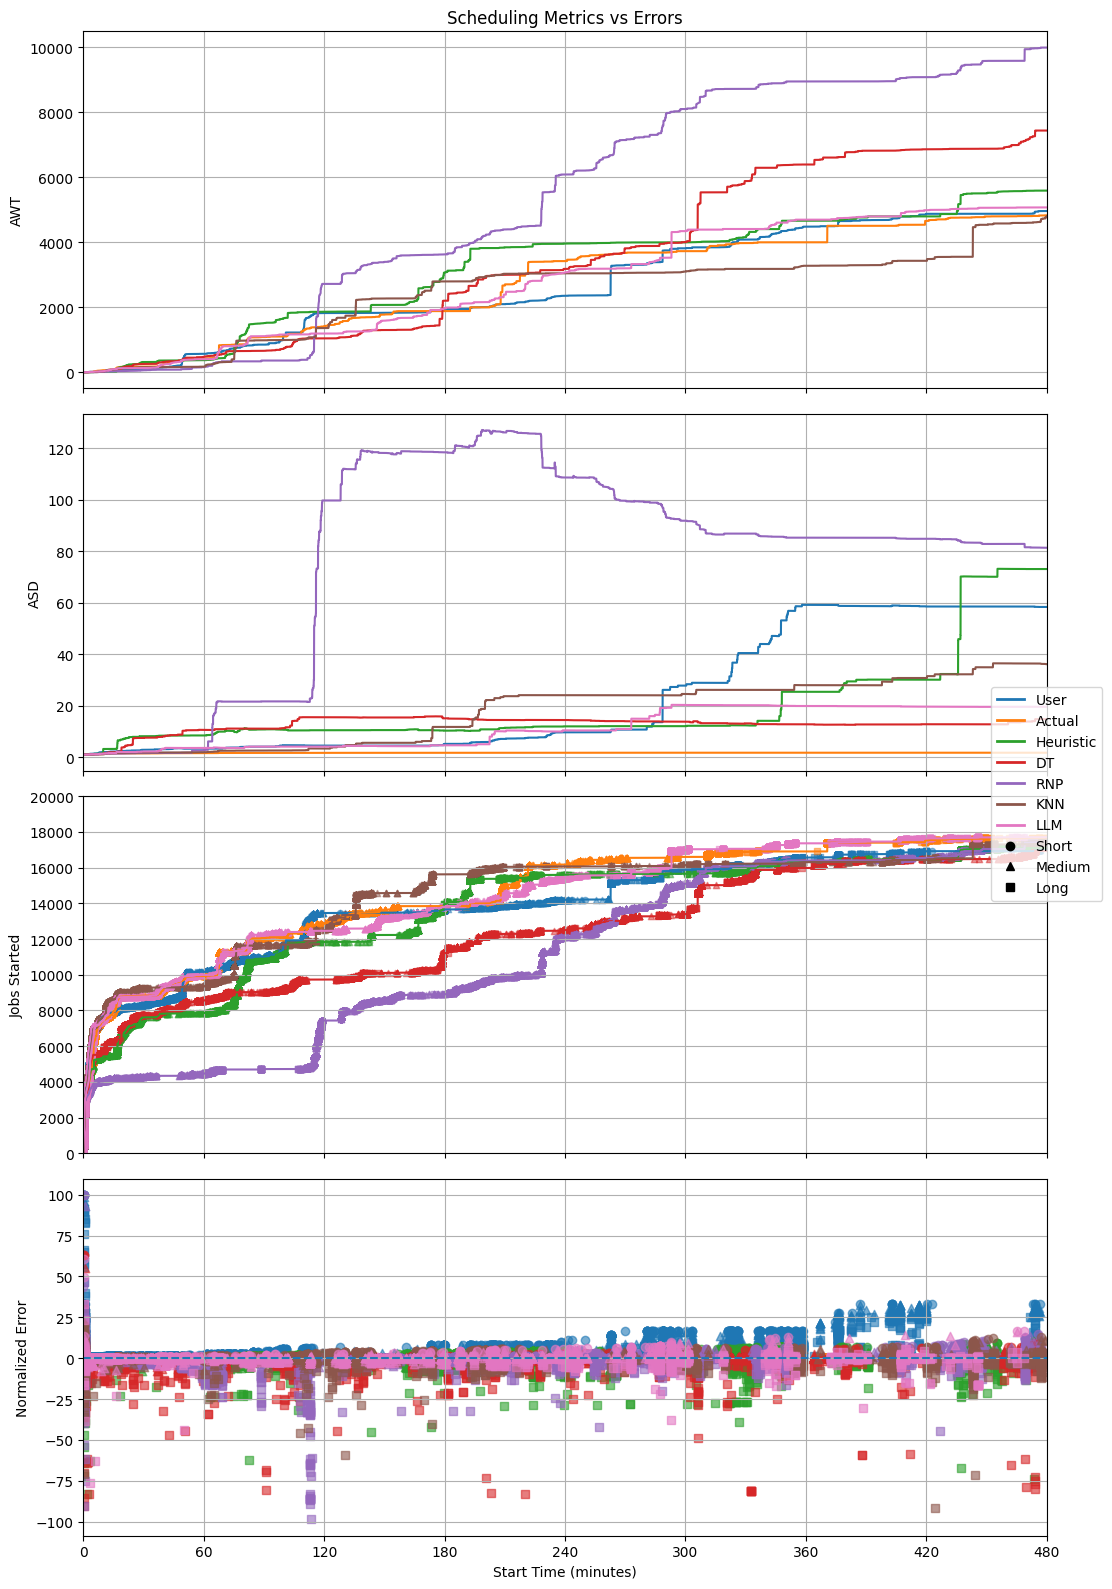

In [15]:
plot_metrics_with_errors(
    metrics, 
    err_df, 
    labels,
    t_start=0,
    t_end=28801,
    image_path="images/18000x158976/metrics_vs_errors.png")

#### Detailed view

### Job's Duration Class in Time-Window

In [16]:
t_w = [
    [0, 70], 
    [70, 370], 
    [360, 420], 
    [690, 930], 
    [50*60, 60*60],
    [105*60, 145*60],
]

Grafico salvato in: images/18000x158976/job_count_vs_actual_combined.png


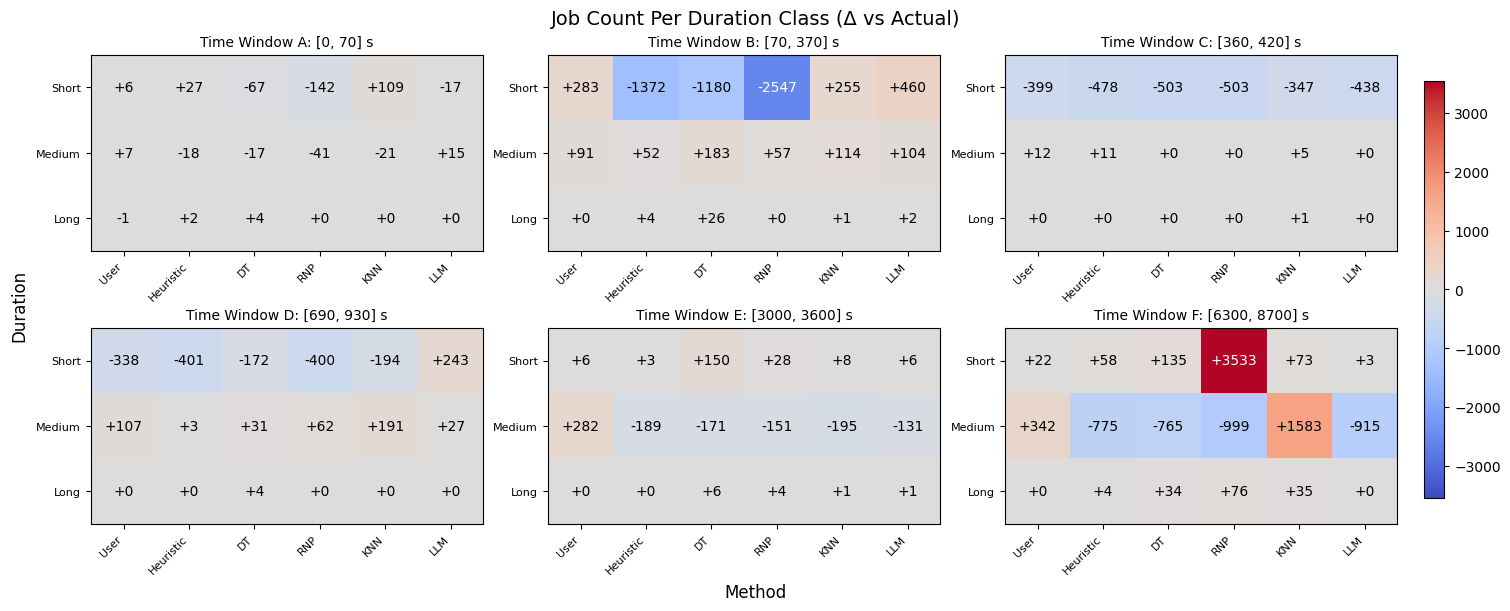

In [17]:
plot_duration_vs_methods_differences_multi(
    err_df,
    t_w,  
    image_path="images/18000x158976/job_count_vs_actual_combined.png"
)

Grafico salvato in: images/18000x158976/job_count_vs_actual_70_370.png


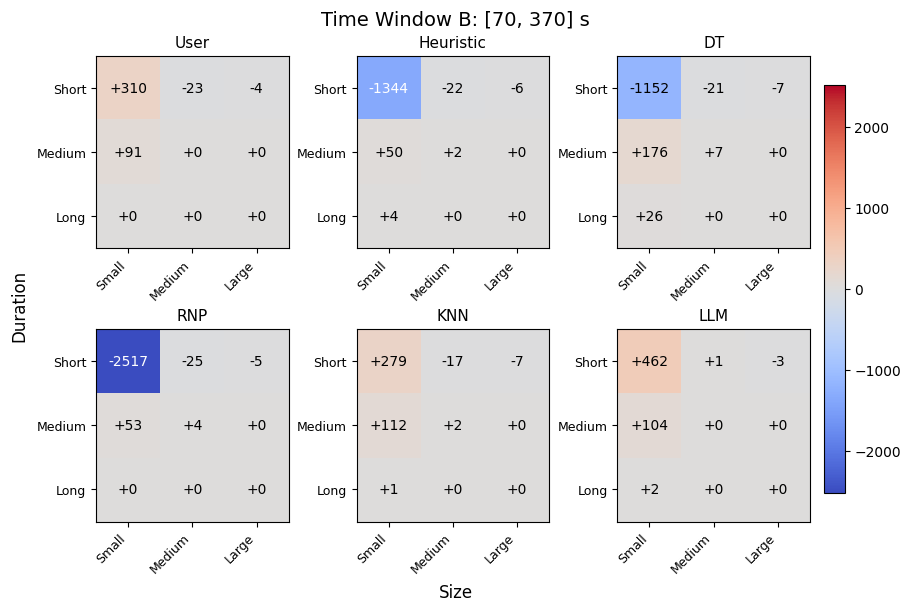

In [18]:
plot_job_class_matrix_differences(err_df, t_start=70, t_end=370, image_path="images/18000x158976/job_count_vs_actual_70_370.png")

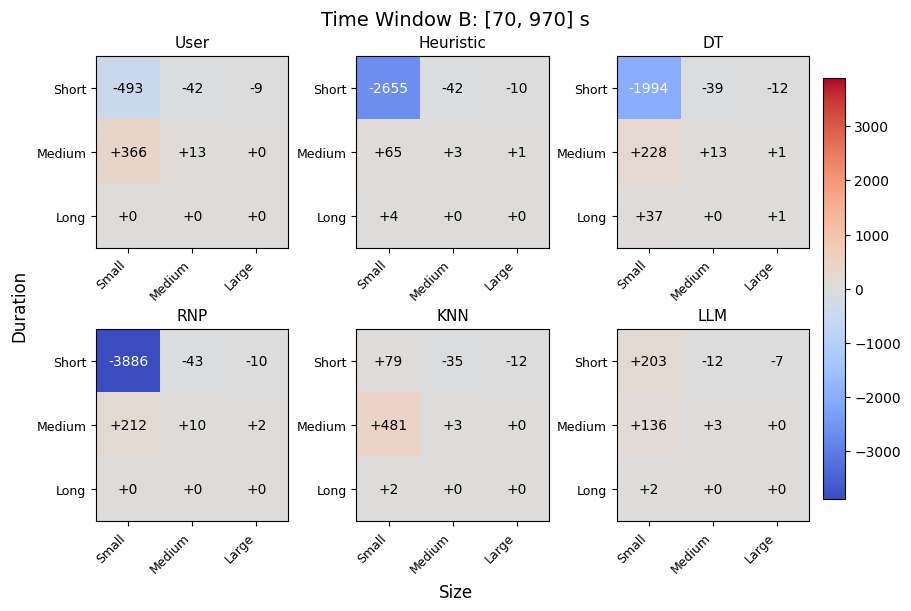

In [19]:
plot_job_class_matrix_differences(err_df, t_start=70, t_end=970)

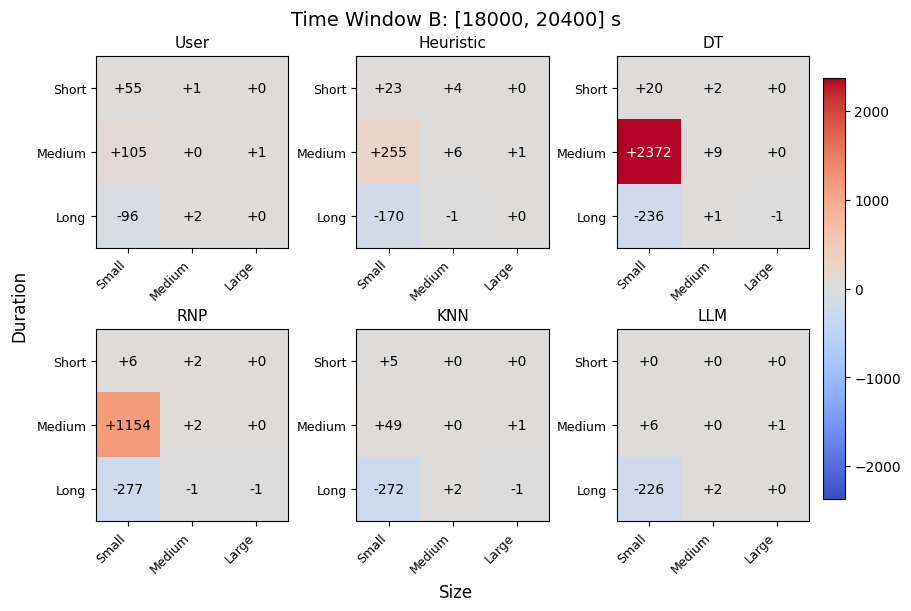

In [19]:
plot_job_class_matrix_differences(err_df, t_start=300*60, t_end=340*60)

### Critical Jobs

In [21]:
job_ids = []

filtered_workload = err_df[err_df.st_user.between(70,970)].copy()
filtered_workload = filtered_workload[filtered_workload.duration_class.isin(["Medium", "Long"])]
filtered_workload = filtered_workload[filtered_workload.size_class.isin(["Medium", "Large"])]
job_ids.extend(filtered_workload.job_id.tolist())

filtered_workload = err_df[err_df.st_heuristic.between(70,970)].copy()
filtered_workload = filtered_workload[filtered_workload.duration_class.isin(["Medium", "Long"])]
filtered_workload = filtered_workload[filtered_workload.size_class.isin(["Medium", "Large"])]
job_ids.extend(filtered_workload.job_id.tolist())

filtered_workload = err_df[err_df.st_dt.between(70,970)].copy()
filtered_workload = filtered_workload[filtered_workload.duration_class.isin(["Medium", "Long"])]
filtered_workload = filtered_workload[filtered_workload.size_class.isin(["Medium", "Large"])]
job_ids.extend(filtered_workload.job_id.tolist())

filtered_workload = err_df[err_df.st_rnp.between(70,970)].copy()
filtered_workload = filtered_workload[filtered_workload.duration_class.isin(["Medium", "Long"])]
filtered_workload = filtered_workload[filtered_workload.size_class.isin(["Medium", "Large"])]
job_ids.extend(filtered_workload.job_id.tolist())

job_ids_short = job_ids.copy()

job_ids = list(set(job_ids))
job_ids_short = list(set(job_ids_short))

print(job_ids)

[9701377, 8701967, 8749209, 32749209, 53708059, 8738338, 8755239, 107720873, 21709482, 9709482, 13720873, 15720873, 9720873, 8745264, 14744378, 22744378, 8744640, 8725062, 8732879, 29690193, 8721748, 8767957, 22708059, 8744542, 8734951, 90720873, 48720873, 14720873, 148720873, 32720873, 8766314, 14709482, 8709482, 8769011, 8768116, 8706552, 11744378, 8744444]


In [ ]:
methods = ["User", "Actual", "Heuristic", "DT", "RNP"]
methods = None

In [ ]:
plot_job_errors_across_methods(
    metrics,
    err_df,
    labels,
    job_ids_short,
    methods_to_plot=methods,
    t_start=0,
    t_end=7201,
    error_window=(-30, 30),
    utilization_window=(90, 100),
    image_path="images/18000x158976/util_vs_critical_errors.png"
)

In [ ]:
critical = err_df.merge(
    workload_df,
    on="job_id",
    how="left"
)

critical = critical.merge(
    predictions,
    on="job_id",
    how="left"
)

selected_columns = ["job_id", "submit_time", "Run Time", "Number of Allocated Nodes",
           "st_actual", 
           "pred_runtime_user", "st_user", 
           "pred_runtime_heuristic", "st_heuristic", 
           "pred_runtime_dt", "st_dt", 
           "pred_runtime_rnp", "st_rnp", 
           "pred_runtime_knn", "st_knn", 
           "pred_runtime_llm", "st_llm", 
          ]

column_names = ["Job ID", "Submit Time", "Runtime", "Number of Nodes",
           "Optimal Start Time", 
           "Runtime (User)", "Start Time (User)", 
           "Runtime (Heuristic)", "Start Time (Heuristic)", 
           "Runtime (DT)", "Start Time (DT)", 
           "Runtime (RNP)", "Start Time (RNP)", 
           "Runtime (KNN)", "Start Time (KNN)", 
           "Runtime (LLM)", "Start Time (LLM)", 
          ]

critical = critical[selected_columns]
critical = critical[critical.job_id.isin(job_ids)]
critical.columns = column_names

critical

In [ ]:
critical["Estimation Error (User)"] = critical["Runtime (User)"] - critical["Runtime"]
critical["∆ Start Time (User)"] = critical["Start Time (User)"] - critical["Optimal Start Time"]

critical["Estimation Error (Heuristic)"] = critical["Runtime (Heuristic)"] - critical["Runtime"]
critical["∆ Start Time (Heuristic)"] = critical["Start Time (Heuristic)"] - critical["Optimal Start Time"]

critical["Estimation Error (DT)"] = critical["Runtime (DT)"] - critical["Runtime"]
critical["∆ Start Time (DT)"] = critical["Start Time (DT)"] - critical["Optimal Start Time"]

critical["Estimation Error (RNP)"] = critical["Runtime (RNP)"] - critical["Runtime"]
critical["∆ Start Time (RNP)"] = critical["Start Time (RNP)"] - critical["Optimal Start Time"]

critical["Estimation Error (KNN)"] = critical["Runtime (KNN)"] - critical["Runtime"]
critical["∆ Start Time (KNN)"] = critical["Start Time (KNN)"] - critical["Optimal Start Time"]

critical["Estimation Error (LLM)"] = critical["Runtime (LLM)"] - critical["Runtime"]
critical["∆ Start Time (LLM)"] = critical["Start Time (LLM)"] - critical["Optimal Start Time"]


final_columns = ["Job ID", "Submit Time", "Runtime", "Number of Nodes",
           "Optimal Start Time", 
           "Estimation Error (User)", "∆ Start Time (User)", 
           "Estimation Error (Heuristic)", "∆ Start Time (Heuristic)", 
           "Estimation Error (DT)", "∆ Start Time (DT)", 
           "Estimation Error (RNP)", "∆ Start Time (RNP)", 
           "Estimation Error (KNN)", "∆ Start Time (KNN)", 
           "Estimation Error (LLM)", "∆ Start Time (LLM)", 
          ]

critical = critical[final_columns]

critical

## Average System Utilization

In [22]:
print("User      =", metrics_user['average_utilization'])
print("Actual    =", metrics_actual['average_utilization'])
print("Heuristic =", metrics_heuristic['average_utilization'])
print("DT        =", metrics_dt['average_utilization'])
print("RNP       =", metrics_rnp['average_utilization'])
print("KNN       =", metrics_knn['average_utilization'])
print("LLM       =", metrics_llm['average_utilization'])

User      = 0.20366177402377034
Actual    = 0.20574099788632894
Heuristic = 0.20534033797062
DT        = 0.20443539737859884
RNP       = 0.20814830654172778
KNN       = 0.2041848156331098
LLM       = 0.20494829828631064


# Heavy 2

## System Metrics Computation

In [14]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/fdata/fdata_18k_2.swf',
    header=None,
    sep='\t'
)
workload_df.columns = workload_column_names
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})


# =========================================================
# ACTUAL
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_2/fdata_18k_2_SJF_Oracle.swf'
exec_df = load_swf(filepath, sim_start_time)

df_oracle = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_oracle = df_oracle.sort_values("start_time").reset_index(drop=True)
df_oracle = df_oracle[column_names]

err_df_actual = df_oracle.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_actual = assign_job_classes(err_df_actual)
err_df_actual = err_df_actual.rename(columns={"start_time": "st_actual"})
err_df_actual["err_actual"] = 0
err_df_actual = err_df_actual[["job_id", "duration_class", "size_class", "st_actual", "err_actual"]]

metrics_actual = compute_system_metrics(df_oracle, err_df_actual)

# sa_metrics_actual = compute_ordering_metrics(df_oracle, predictions, pred_col="gt_runtime")


# =========================================================
# USER
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_2/fdata_18k_2_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

df_user = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_user = df_user.sort_values("start_time").reset_index(drop=True)
df_user = df_user[column_names]

err_df_user = df_user.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_user = assign_job_classes(err_df_user)
err_df_user = err_df_user.rename(columns={"start_time": "st_user"})
err_df_user = err_df_user[["job_id", "duration_class", "size_class", "st_user", "err_user"]]

metrics_user = compute_system_metrics(df_user, err_df_user)

sa_metrics_user = compute_ordering_metrics(df_user, predictions, pred_col="pred_runtime_user")


# =========================================================
# HEURISTIC
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_2/fdata_18k_2_SJF_H.swf'
exec_df = load_swf(filepath, sim_start_time)

df_heuristic = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_heuristic = df_heuristic.sort_values("start_time").reset_index(drop=True)
df_heuristic = df_heuristic[column_names]

err_df_heuristic = df_heuristic.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_heuristic = assign_job_classes(err_df_heuristic)
err_df_heuristic = err_df_heuristic.rename(columns={"start_time": "st_heuristic"})
err_df_heuristic = err_df_heuristic[["job_id", "duration_class", "size_class", "st_heuristic", "err_heuristic"]]

metrics_heuristic = compute_system_metrics(df_heuristic, err_df_heuristic)

sa_metrics_heuristic = compute_ordering_metrics(df_heuristic, predictions, pred_col="pred_runtime_heuristic")


# =========================================================
# DT
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_2/fdata_18k_2_SJF_DT.swf'
exec_df = load_swf(filepath, sim_start_time)


df_dt = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_dt = df_dt.sort_values("start_time").reset_index(drop=True)
df_dt = df_dt[column_names]

err_df_dt = df_dt.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_dt = assign_job_classes(err_df_dt)
err_df_dt = err_df_dt.rename(columns={"start_time": "st_dt"})
err_df_dt = err_df_dt[["job_id", "duration_class", "size_class", "st_dt", "err_dt"]]

metrics_dt = compute_system_metrics(df_dt, err_df_dt)

sa_metrics_dt = compute_ordering_metrics(df_dt, predictions, pred_col="pred_runtime_dt")


# =========================================================
# RNP
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_2/fdata_18k_2_SJF_RNP.swf'
exec_df = load_swf(filepath, sim_start_time)

df_rnp = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_rnp = df_rnp.sort_values("start_time").reset_index(drop=True)
df_rnp = df_rnp[column_names]

err_df_rnp = df_rnp.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_rnp = assign_job_classes(err_df_rnp)
err_df_rnp = err_df_rnp.rename(columns={"start_time": "st_rnp"})
err_df_rnp = err_df_rnp[["job_id", "duration_class", "size_class", "st_rnp", "err_rnp"]]

metrics_rnp = compute_system_metrics(df_rnp, err_df_rnp)

sa_metrics_rnp = compute_ordering_metrics(df_rnp, predictions, pred_col="pred_runtime_rnp")


# =========================================================
# KNN
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_2/fdata_18k_2_SJF_KNN.swf'
exec_df = load_swf(filepath, sim_start_time)

df_knn = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_knn = df_knn.sort_values("start_time").reset_index(drop=True)
df_knn = df_knn[column_names]

err_df_knn = df_knn.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_knn = assign_job_classes(err_df_knn)
err_df_knn = err_df_knn.rename(columns={"start_time": "st_knn"})
err_df_knn = err_df_knn[["job_id", "duration_class", "size_class", "st_knn", "err_knn"]]

metrics_knn = compute_system_metrics(df_knn, err_df_knn)

sa_metrics_knn = compute_ordering_metrics(df_knn, predictions, pred_col="pred_runtime_knn")


# =========================================================
# LLM
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_2/fdata_18k_2_SJF_LLM.swf'
exec_df = load_swf(filepath, sim_start_time)

df_llm = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_llm = df_llm.sort_values("start_time").reset_index(drop=True)
df_llm = df_llm[column_names]

err_df_llm = df_llm.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_llm = assign_job_classes(err_df_llm)
err_df_llm = err_df_llm.rename(columns={"start_time": "st_llm"})
err_df_llm = err_df_llm[["job_id", "duration_class", "size_class", "st_llm", "err_llm"]]

metrics_llm = compute_system_metrics(df_llm, err_df_llm)

sa_metrics_llm = compute_ordering_metrics(df_llm, predictions, pred_col="pred_runtime_llm")

In [15]:
print(f'"OD_AWT_F2": [{sa_metrics_user["OD_AWT"]}, 0, {sa_metrics_heuristic["OD_AWT"]}, {sa_metrics_dt["OD_AWT"]}, {sa_metrics_rnp["OD_AWT"]}, {sa_metrics_knn["OD_AWT"]}, {sa_metrics_llm["OD_AWT"]}],') 
print(f'"OD_ASD_F2": [{sa_metrics_user["OD_ASD"]}, 0, {sa_metrics_heuristic["OD_ASD"]}, {sa_metrics_dt["OD_ASD"]}, {sa_metrics_rnp["OD_ASD"]}, {sa_metrics_knn["OD_ASD"]}, {sa_metrics_llm["OD_ASD"]}]')

"OD_AWT_F2": [294227860661.2166, 0, 371377188796.13116, 542074527365.93835, 659385529770.1708, 295366545028.0533, 53420255234.190926],
"OD_ASD_F2": [1860221065.8055582, 0, 1763878046.5297408, 723529597.3914655, 2769303132.3301415, 458782864.03665674, 112174106.28752576]


## Merge metrics and errors

In [24]:
metrics = [
    metrics_user,
    metrics_actual,
    metrics_heuristic,
    metrics_dt,
    metrics_rnp,
    metrics_knn,
    metrics_llm
]

labels = [
    "User",
    "Actual",
    "Heuristic",
    "DT",
    "RNP",
    "KNN",
    "LLM"
]

In [25]:
err_df = err_df_user.merge(
            err_df_actual[["job_id", "st_actual", "err_actual"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_heuristic[["job_id", "st_heuristic", "err_heuristic"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_dt[["job_id", "st_dt", "err_dt"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_rnp[["job_id", "st_rnp", "err_rnp"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_knn[["job_id", "st_knn", "err_knn"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_llm[["job_id", "st_llm", "err_llm"]],
            on="job_id",
            how="left"
)

## Plots

### System Utilization

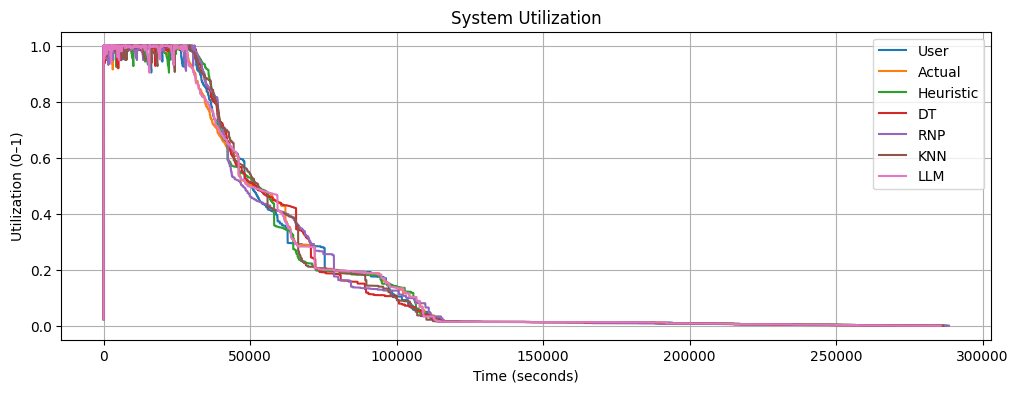

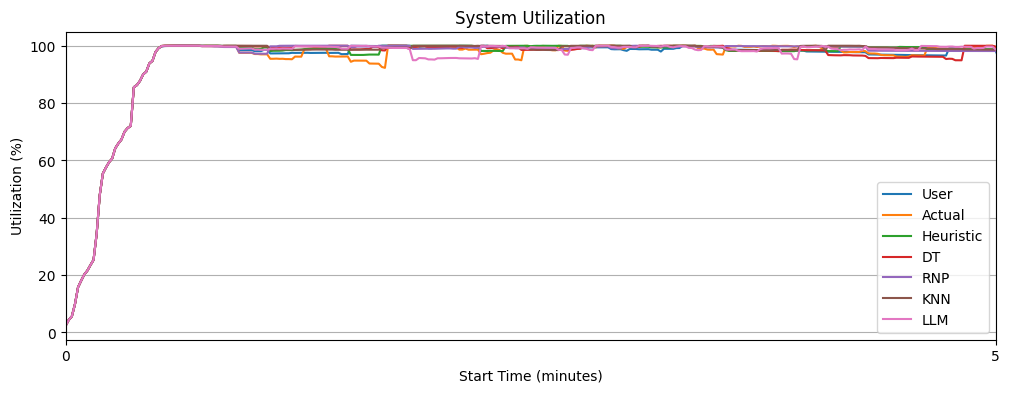

C:\Users\trap9\AppData\Local\Temp\ipykernel_606872\2120994538.py:34: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(0, max(ticks))


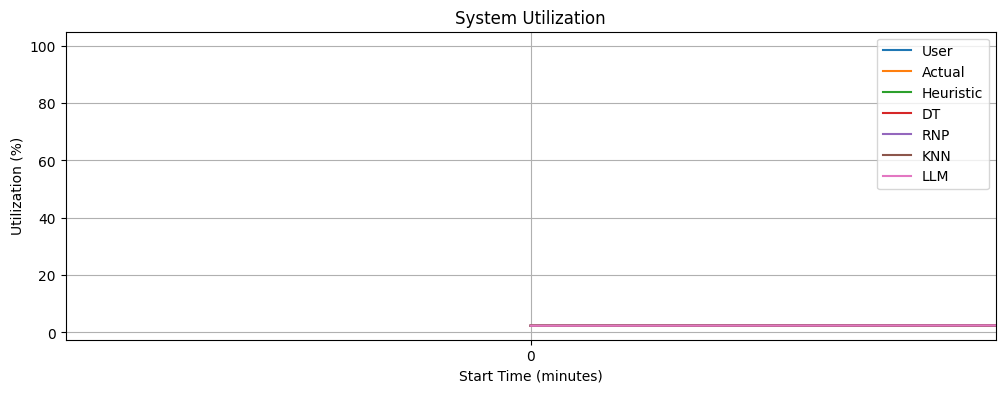

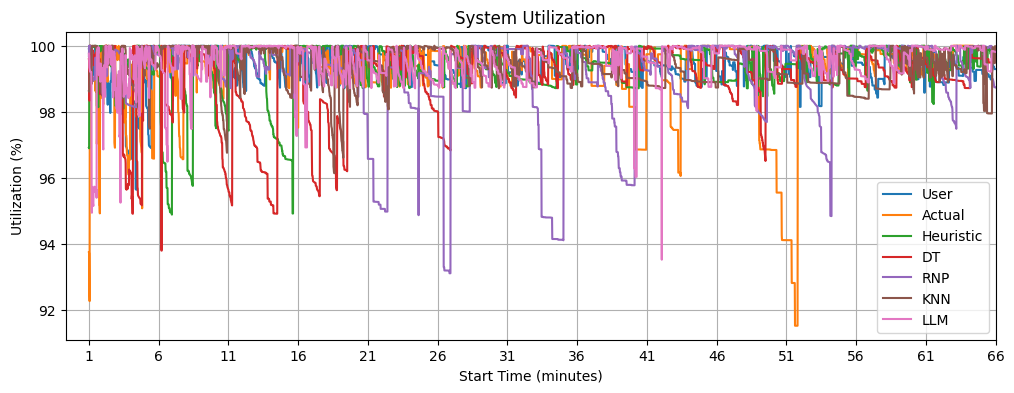

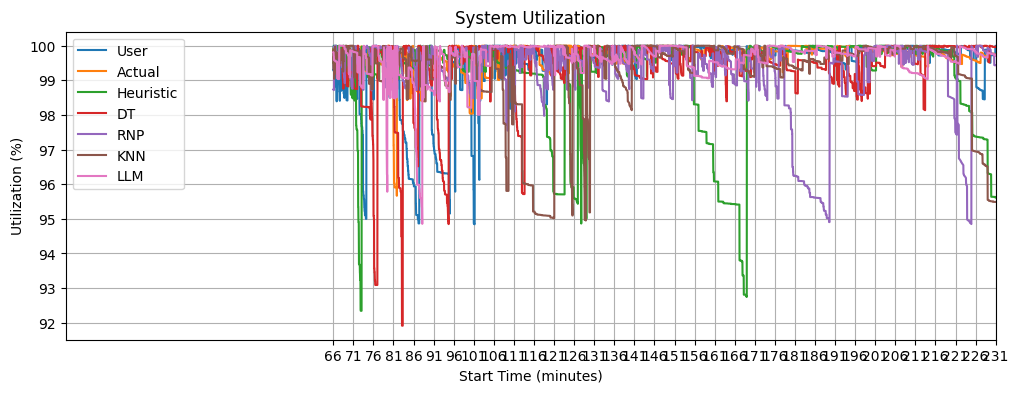

In [26]:
plot_metrics(metrics, labels)

plot_metrics_window(metrics, labels, 0, 301)

plot_metrics_window(metrics, labels, 0, 101)

plot_metrics_window(metrics, labels, 100, 4001)

plot_metrics_window(metrics, labels, 4000, 14001)

### System Metrics vs Prediction Error

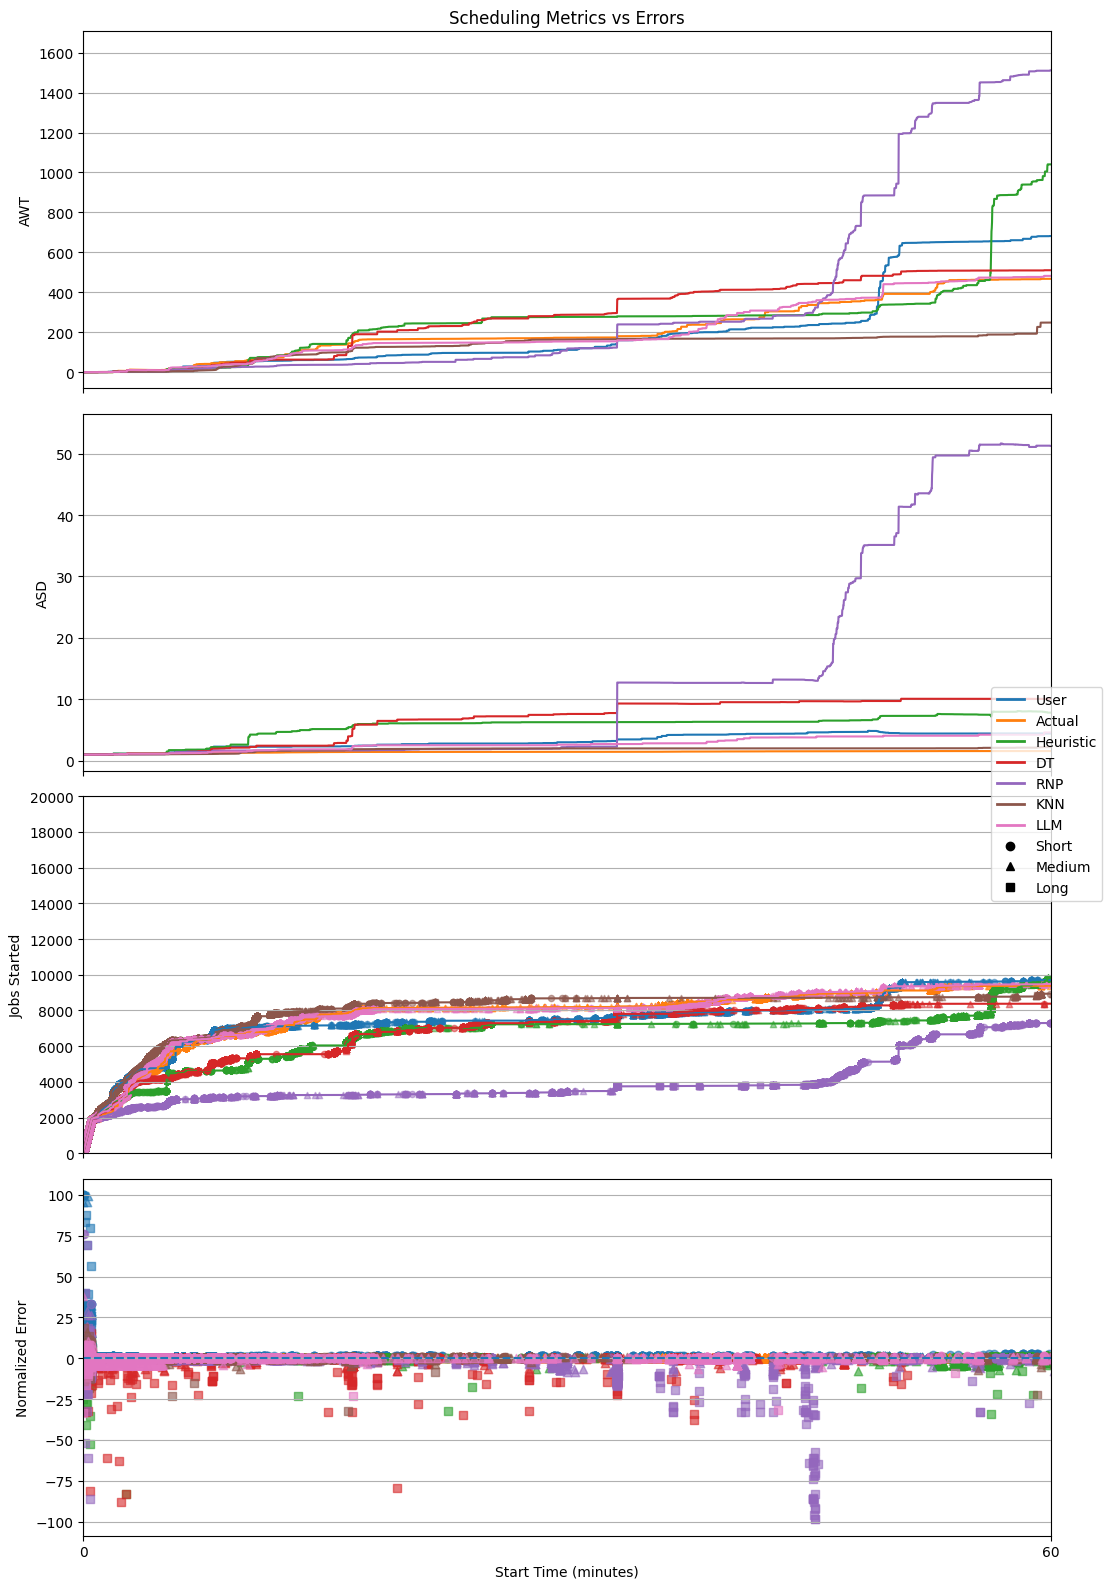

In [27]:
plot_metrics_with_errors(metrics, err_df, labels)

## Average System Utilization

In [28]:
print("User      =", metrics_user['average_utilization'])
print("Actual    =", metrics_actual['average_utilization'])
print("Heuristic =", metrics_heuristic['average_utilization'])
print("DT        =", metrics_dt['average_utilization'])
print("RNP       =", metrics_rnp['average_utilization'])
print("KNN       =", metrics_knn['average_utilization'])
print("LLM       =", metrics_llm['average_utilization'])

User      = 0.20839556585640745
Actual    = 0.2099988164620298
Heuristic = 0.20804982756092555
DT        = 0.20884427330185304
RNP       = 0.20772898776474788
KNN       = 0.20919922999494361
LLM       = 0.20977540330212102


# Heavy 3

## System Metrics Computation

In [16]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/fdata/fdata_18k_3.swf',
    header=None,
    sep='\t'
)
workload_df.columns = workload_column_names
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})


# =========================================================
# ACTUAL
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_3/fdata_18k_3_SJF_Oracle.swf'
exec_df = load_swf(filepath, sim_start_time)

df_oracle = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_oracle = df_oracle.sort_values("start_time").reset_index(drop=True)
df_oracle = df_oracle[column_names]

err_df_actual = df_oracle.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_actual = assign_job_classes(err_df_actual)
err_df_actual = err_df_actual.rename(columns={"start_time": "st_actual"})
err_df_actual["err_actual"] = 0
err_df_actual = err_df_actual[["job_id", "duration_class", "size_class", "st_actual", "err_actual"]]

metrics_actual = compute_system_metrics(df_oracle, err_df_actual)

# sa_metrics_actual = compute_ordering_metrics(df_oracle, predictions, pred_col="gt_runtime")


# =========================================================
# USER
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_3/fdata_18k_3_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

df_user = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_user = df_user.sort_values("start_time").reset_index(drop=True)
df_user = df_user[column_names]

err_df_user = df_user.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_user = assign_job_classes(err_df_user)
err_df_user = err_df_user.rename(columns={"start_time": "st_user"})
err_df_user = err_df_user[["job_id", "duration_class", "size_class", "st_user", "err_user"]]

metrics_user = compute_system_metrics(df_user, err_df_user)

sa_metrics_user = compute_ordering_metrics(df_user, predictions, pred_col="pred_runtime_user")


# =========================================================
# HEURISTIC
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_3/fdata_18k_3_SJF_H.swf'
exec_df = load_swf(filepath, sim_start_time)

df_heuristic = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_heuristic = df_heuristic.sort_values("start_time").reset_index(drop=True)
df_heuristic = df_heuristic[column_names]

err_df_heuristic = df_heuristic.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_heuristic = assign_job_classes(err_df_heuristic)
err_df_heuristic = err_df_heuristic.rename(columns={"start_time": "st_heuristic"})
err_df_heuristic = err_df_heuristic[["job_id", "duration_class", "size_class", "st_heuristic", "err_heuristic"]]

metrics_heuristic = compute_system_metrics(df_heuristic, err_df_heuristic)

sa_metrics_heuristic = compute_ordering_metrics(df_heuristic, predictions, pred_col="pred_runtime_heuristic")


# =========================================================
# DT
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_3/fdata_18k_3_SJF_DT.swf'
exec_df = load_swf(filepath, sim_start_time)


df_dt = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_dt = df_dt.sort_values("start_time").reset_index(drop=True)
df_dt = df_dt[column_names]

err_df_dt = df_dt.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_dt = assign_job_classes(err_df_dt)
err_df_dt = err_df_dt.rename(columns={"start_time": "st_dt"})
err_df_dt = err_df_dt[["job_id", "duration_class", "size_class", "st_dt", "err_dt"]]

metrics_dt = compute_system_metrics(df_dt, err_df_dt)

sa_metrics_dt = compute_ordering_metrics(df_dt, predictions, pred_col="pred_runtime_dt")


# =========================================================
# RNP
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_3/fdata_18k_3_SJF_RNP.swf'
exec_df = load_swf(filepath, sim_start_time)

df_rnp = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_rnp = df_rnp.sort_values("start_time").reset_index(drop=True)
df_rnp = df_rnp[column_names]

err_df_rnp = df_rnp.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_rnp = assign_job_classes(err_df_rnp)
err_df_rnp = err_df_rnp.rename(columns={"start_time": "st_rnp"})
err_df_rnp = err_df_rnp[["job_id", "duration_class", "size_class", "st_rnp", "err_rnp"]]

metrics_rnp = compute_system_metrics(df_rnp, err_df_rnp)

sa_metrics_rnp = compute_ordering_metrics(df_rnp, predictions, pred_col="pred_runtime_rnp")


# =========================================================
# KNN
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_3/fdata_18k_3_SJF_KNN.swf'
exec_df = load_swf(filepath, sim_start_time)

df_knn = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_knn = df_knn.sort_values("start_time").reset_index(drop=True)
df_knn = df_knn[column_names]

err_df_knn = df_knn.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_knn = assign_job_classes(err_df_knn)
err_df_knn = err_df_knn.rename(columns={"start_time": "st_knn"})
err_df_knn = err_df_knn[["job_id", "duration_class", "size_class", "st_knn", "err_knn"]]

metrics_knn = compute_system_metrics(df_knn, err_df_knn)

sa_metrics_knn = compute_ordering_metrics(df_knn, predictions, pred_col="pred_runtime_knn")


# =========================================================
# LLM
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_3/fdata_18k_3_SJF_LLM.swf'
exec_df = load_swf(filepath, sim_start_time)

df_llm = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_llm = df_llm.sort_values("start_time").reset_index(drop=True)
df_llm = df_llm[column_names]

err_df_llm = df_llm.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_llm = assign_job_classes(err_df_llm)
err_df_llm = err_df_llm.rename(columns={"start_time": "st_llm"})
err_df_llm = err_df_llm[["job_id", "duration_class", "size_class", "st_llm", "err_llm"]]

metrics_llm = compute_system_metrics(df_llm, err_df_llm)

sa_metrics_llm = compute_ordering_metrics(df_llm, predictions, pred_col="pred_runtime_llm")

In [17]:
print(f'"OD_AWT_F3": [{sa_metrics_user["OD_AWT"]}, 0, {sa_metrics_heuristic["OD_AWT"]}, {sa_metrics_dt["OD_AWT"]}, {sa_metrics_rnp["OD_AWT"]}, {sa_metrics_knn["OD_AWT"]}, {sa_metrics_llm["OD_AWT"]}],') 
print(f'"OD_ASD_F3": [{sa_metrics_user["OD_ASD"]}, 0, {sa_metrics_heuristic["OD_ASD"]}, {sa_metrics_dt["OD_ASD"]}, {sa_metrics_rnp["OD_ASD"]}, {sa_metrics_knn["OD_ASD"]}, {sa_metrics_llm["OD_ASD"]}]')

"OD_AWT_F3": [302871652471.52527, 0, 362855461528.12897, 645215989265.4724, 731497882897.2657, 171390080762.25293, 55684556602.91508],
"OD_ASD_F3": [1973191172.8347588, 0, 2047120001.3807008, 993214132.7619069, 3601383743.0165854, 439385230.9084551, 132137600.29267566]


## Merge metrics and errors

In [30]:
metrics = [
    metrics_user,
    metrics_actual,
    metrics_heuristic,
    metrics_dt,
    metrics_rnp,
    metrics_knn,
    metrics_llm
]

labels = [
    "User",
    "Actual",
    "Heuristic",
    "DT",
    "RNP",
    "KNN",
    "LLM"
]

In [31]:
err_df = err_df_user.merge(
            err_df_actual[["job_id", "st_actual", "err_actual"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_heuristic[["job_id", "st_heuristic", "err_heuristic"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_dt[["job_id", "st_dt", "err_dt"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_rnp[["job_id", "st_rnp", "err_rnp"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_knn[["job_id", "st_knn", "err_knn"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_llm[["job_id", "st_llm", "err_llm"]],
            on="job_id",
            how="left"
)

## Plots

### System Utilization

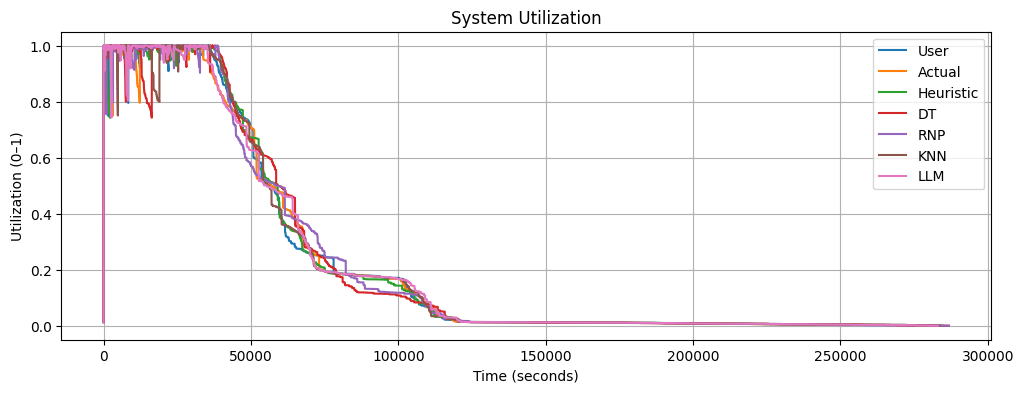

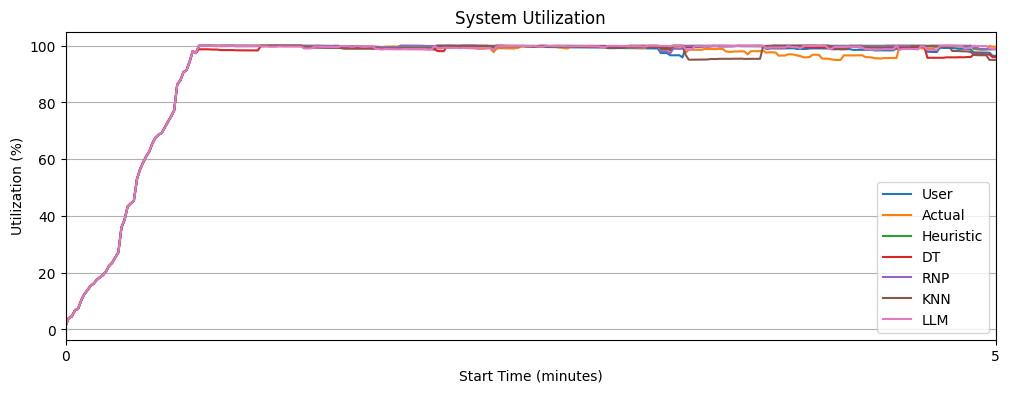

C:\Users\trap9\AppData\Local\Temp\ipykernel_606872\2120994538.py:34: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(0, max(ticks))


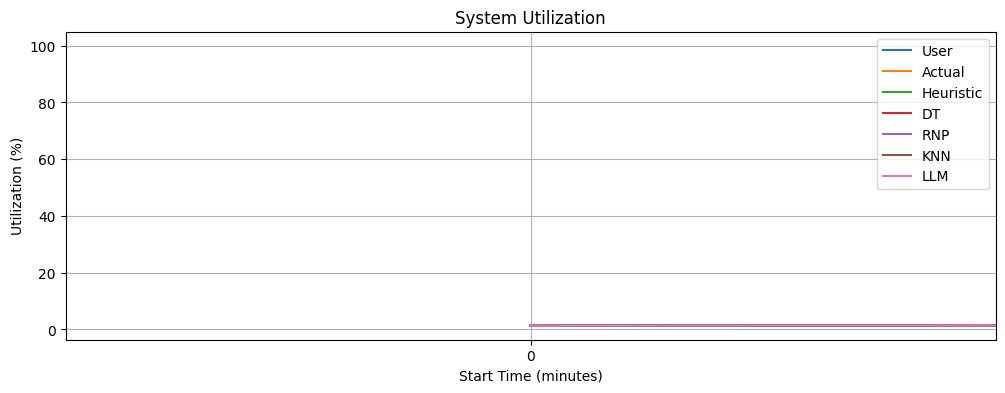

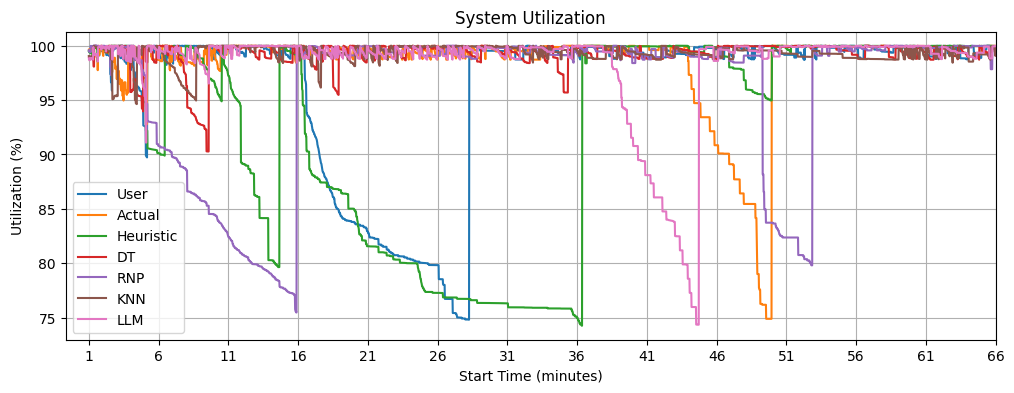

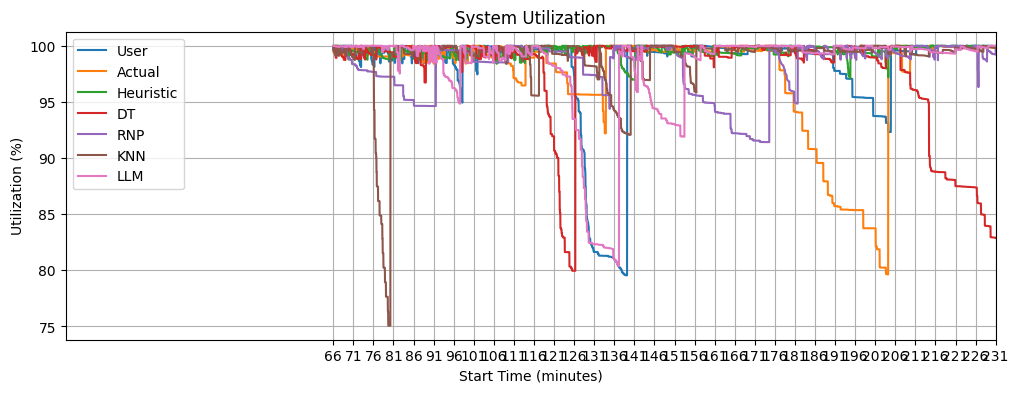

In [32]:
plot_metrics(metrics, labels)

plot_metrics_window(metrics, labels, 0, 301)

plot_metrics_window(metrics, labels, 0, 101)

plot_metrics_window(metrics, labels, 100, 4001)

plot_metrics_window(metrics, labels, 4000, 14001)

### System Metrics vs Prediction Error

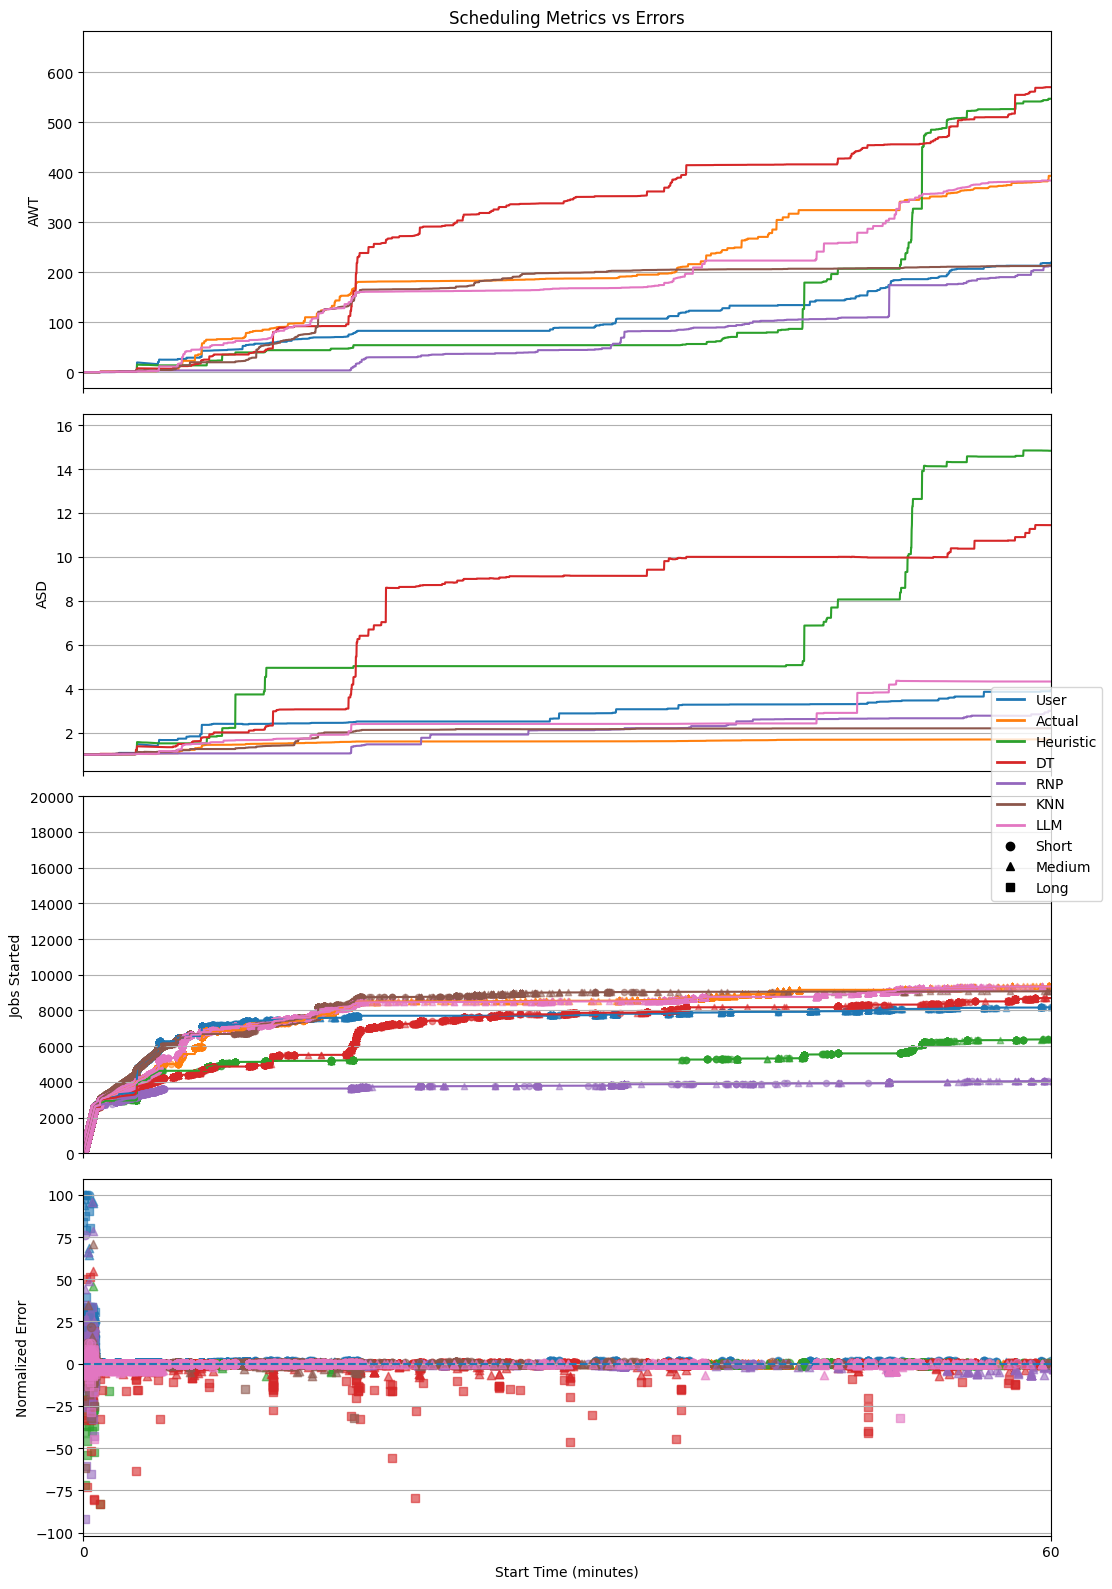

In [33]:
plot_metrics_with_errors(metrics, err_df, labels)

## Average System Utilization

In [34]:
print("User      =", metrics_user['average_utilization'])
print("Actual    =", metrics_actual['average_utilization'])
print("Heuristic =", metrics_heuristic['average_utilization'])
print("DT        =", metrics_dt['average_utilization'])
print("RNP       =", metrics_rnp['average_utilization'])
print("KNN       =", metrics_knn['average_utilization'])
print("LLM       =", metrics_llm['average_utilization'])

User      = 0.22645843779501593
Actual    = 0.22809350805781636
Heuristic = 0.22540297280713534
DT        = 0.2239098892068049
RNP       = 0.22389739985447207
KNN       = 0.22663424405263327
LLM       = 0.22685919397414195


# Heavy 4

## System Metrics Computation

In [18]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/fdata/fdata_18k_4.swf',
    header=None,
    sep='\t'
)
workload_df.columns = workload_column_names
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})


# =========================================================
# ACTUAL
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_4/fdata_18k_4_SJF_Oracle.swf'
exec_df = load_swf(filepath, sim_start_time)

df_oracle = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_oracle = df_oracle.sort_values("start_time").reset_index(drop=True)
df_oracle = df_oracle[column_names]

err_df_actual = df_oracle.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_actual = assign_job_classes(err_df_actual)
err_df_actual = err_df_actual.rename(columns={"start_time": "st_actual"})
err_df_actual["err_actual"] = 0
err_df_actual = err_df_actual[["job_id", "duration_class", "size_class", "st_actual", "err_actual"]]

metrics_actual = compute_system_metrics(df_oracle, err_df_actual)

# sa_metrics_actual = compute_ordering_metrics(df_oracle, predictions, pred_col="gt_runtime")


# =========================================================
# USER
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_4/fdata_18k_4_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

df_user = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_user = df_user.sort_values("start_time").reset_index(drop=True)
df_user = df_user[column_names]

err_df_user = df_user.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_user = assign_job_classes(err_df_user)
err_df_user = err_df_user.rename(columns={"start_time": "st_user"})
err_df_user = err_df_user[["job_id", "duration_class", "size_class", "st_user", "err_user"]]

metrics_user = compute_system_metrics(df_user, err_df_user)

sa_metrics_user = compute_ordering_metrics(df_user, predictions, pred_col="pred_runtime_user")


# =========================================================
# HEURISTIC
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_4/fdata_18k_4_SJF_H.swf'
exec_df = load_swf(filepath, sim_start_time)

df_heuristic = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_heuristic = df_heuristic.sort_values("start_time").reset_index(drop=True)
df_heuristic = df_heuristic[column_names]

err_df_heuristic = df_heuristic.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_heuristic = assign_job_classes(err_df_heuristic)
err_df_heuristic = err_df_heuristic.rename(columns={"start_time": "st_heuristic"})
err_df_heuristic = err_df_heuristic[["job_id", "duration_class", "size_class", "st_heuristic", "err_heuristic"]]

metrics_heuristic = compute_system_metrics(df_heuristic, err_df_heuristic)

sa_metrics_heuristic = compute_ordering_metrics(df_heuristic, predictions, pred_col="pred_runtime_heuristic")


# =========================================================
# DT
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_4/fdata_18k_4_SJF_DT.swf'
exec_df = load_swf(filepath, sim_start_time)


df_dt = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_dt = df_dt.sort_values("start_time").reset_index(drop=True)
df_dt = df_dt[column_names]

err_df_dt = df_dt.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_dt = assign_job_classes(err_df_dt)
err_df_dt = err_df_dt.rename(columns={"start_time": "st_dt"})
err_df_dt = err_df_dt[["job_id", "duration_class", "size_class", "st_dt", "err_dt"]]

metrics_dt = compute_system_metrics(df_dt, err_df_dt)

sa_metrics_dt = compute_ordering_metrics(df_dt, predictions, pred_col="pred_runtime_dt")


# =========================================================
# RNP
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_4/fdata_18k_4_SJF_RNP.swf'
exec_df = load_swf(filepath, sim_start_time)

df_rnp = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_rnp = df_rnp.sort_values("start_time").reset_index(drop=True)
df_rnp = df_rnp[column_names]

err_df_rnp = df_rnp.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_rnp = assign_job_classes(err_df_rnp)
err_df_rnp = err_df_rnp.rename(columns={"start_time": "st_rnp"})
err_df_rnp = err_df_rnp[["job_id", "duration_class", "size_class", "st_rnp", "err_rnp"]]

metrics_rnp = compute_system_metrics(df_rnp, err_df_rnp)

sa_metrics_rnp = compute_ordering_metrics(df_rnp, predictions, pred_col="pred_runtime_rnp")


# =========================================================
# KNN
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_4/fdata_18k_4_SJF_KNN.swf'
exec_df = load_swf(filepath, sim_start_time)

df_knn = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_knn = df_knn.sort_values("start_time").reset_index(drop=True)
df_knn = df_knn[column_names]

err_df_knn = df_knn.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_knn = assign_job_classes(err_df_knn)
err_df_knn = err_df_knn.rename(columns={"start_time": "st_knn"})
err_df_knn = err_df_knn[["job_id", "duration_class", "size_class", "st_knn", "err_knn"]]

metrics_knn = compute_system_metrics(df_knn, err_df_knn)

sa_metrics_knn = compute_ordering_metrics(df_knn, predictions, pred_col="pred_runtime_knn")


# =========================================================
# LLM
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_4/fdata_18k_4_SJF_LLM.swf'
exec_df = load_swf(filepath, sim_start_time)

df_llm = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_llm = df_llm.sort_values("start_time").reset_index(drop=True)
df_llm = df_llm[column_names]

err_df_llm = df_llm.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_llm = assign_job_classes(err_df_llm)
err_df_llm = err_df_llm.rename(columns={"start_time": "st_llm"})
err_df_llm = err_df_llm[["job_id", "duration_class", "size_class", "st_llm", "err_llm"]]

metrics_llm = compute_system_metrics(df_llm, err_df_llm)

sa_metrics_llm = compute_ordering_metrics(df_llm, predictions, pred_col="pred_runtime_llm")

In [19]:
print(f'"OD_AWT_F4": [{sa_metrics_user["OD_AWT"]}, 0, {sa_metrics_heuristic["OD_AWT"]}, {sa_metrics_dt["OD_AWT"]}, {sa_metrics_rnp["OD_AWT"]}, {sa_metrics_knn["OD_AWT"]}, {sa_metrics_llm["OD_AWT"]}],') 
print(f'"OD_ASD_F4": [{sa_metrics_user["OD_ASD"]}, 0, {sa_metrics_heuristic["OD_ASD"]}, {sa_metrics_dt["OD_ASD"]}, {sa_metrics_rnp["OD_ASD"]}, {sa_metrics_knn["OD_ASD"]}, {sa_metrics_llm["OD_ASD"]}]')

"OD_AWT_F4": [321835998870.84784, 0, 355849530374.8574, 774377480726.4027, 740887030560.6981, 222856146510.30865, 80371471654.95036],
"OD_ASD_F4": [2014679864.3514235, 0, 1852392985.7226155, 1366276317.8557684, 3321747978.3195868, 492369112.06712526, 170794820.07098946]


## Merge metrics and errors

In [36]:
metrics = [
    metrics_user,
    metrics_actual,
    metrics_heuristic,
    metrics_dt,
    metrics_rnp,
    metrics_knn,
    metrics_llm
]

labels = [
    "User",
    "Actual",
    "Heuristic",
    "DT",
    "RNP",
    "KNN",
    "LLM"
]

In [37]:
err_df = err_df_user.merge(
            err_df_actual[["job_id", "st_actual", "err_actual"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_heuristic[["job_id", "st_heuristic", "err_heuristic"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_dt[["job_id", "st_dt", "err_dt"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_rnp[["job_id", "st_rnp", "err_rnp"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_knn[["job_id", "st_knn", "err_knn"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_llm[["job_id", "st_llm", "err_llm"]],
            on="job_id",
            how="left"
)

## Plots

### System Utilization

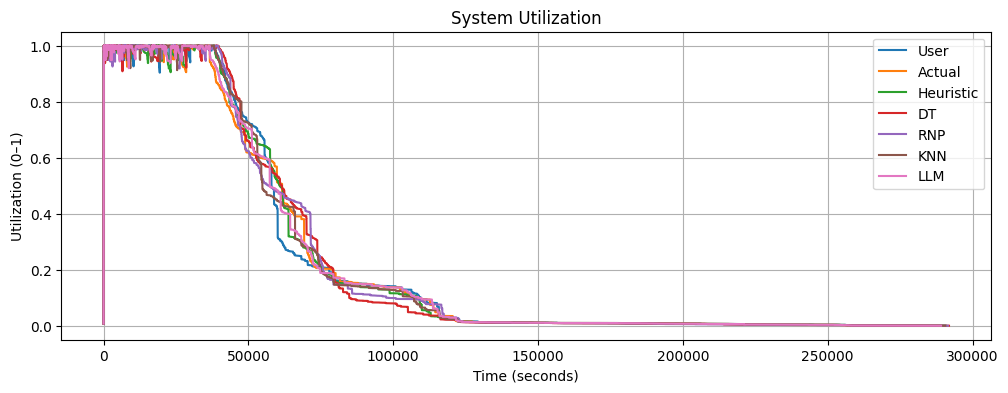

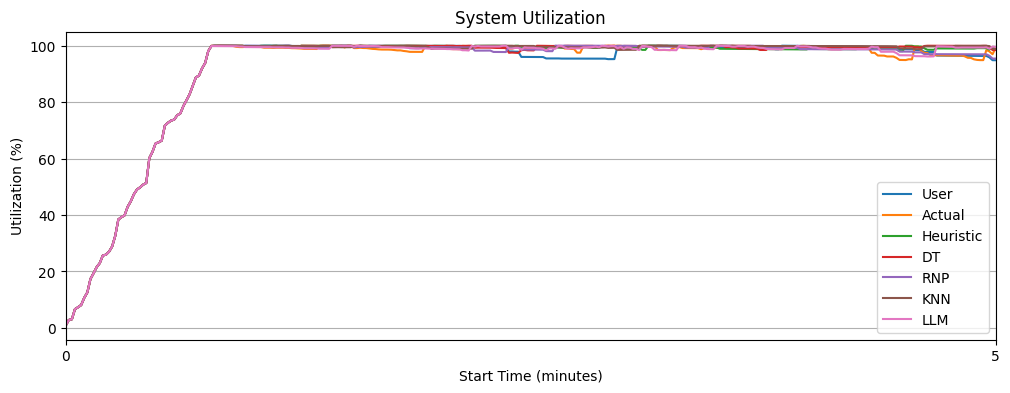

C:\Users\trap9\AppData\Local\Temp\ipykernel_606872\2120994538.py:34: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(0, max(ticks))


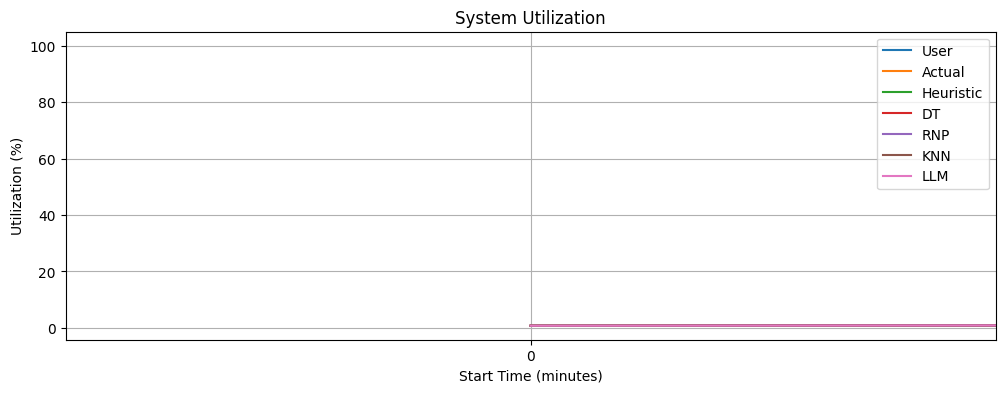

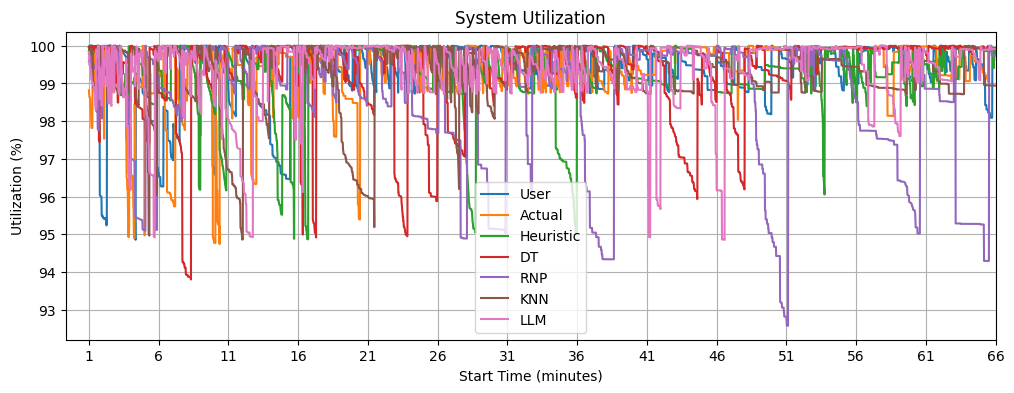

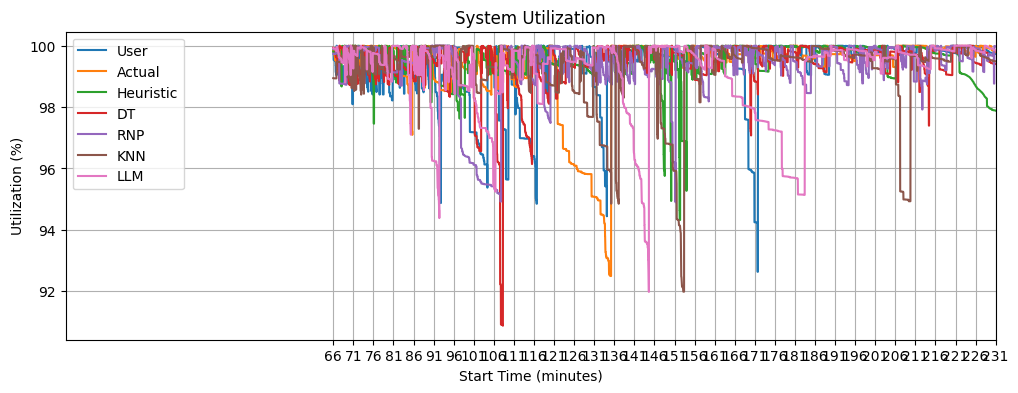

In [38]:
plot_metrics(metrics, labels)

plot_metrics_window(metrics, labels, 0, 301)

plot_metrics_window(metrics, labels, 0, 101)

plot_metrics_window(metrics, labels, 100, 4001)

plot_metrics_window(metrics, labels, 4000, 14001)

### System Metrics vs Prediction Error

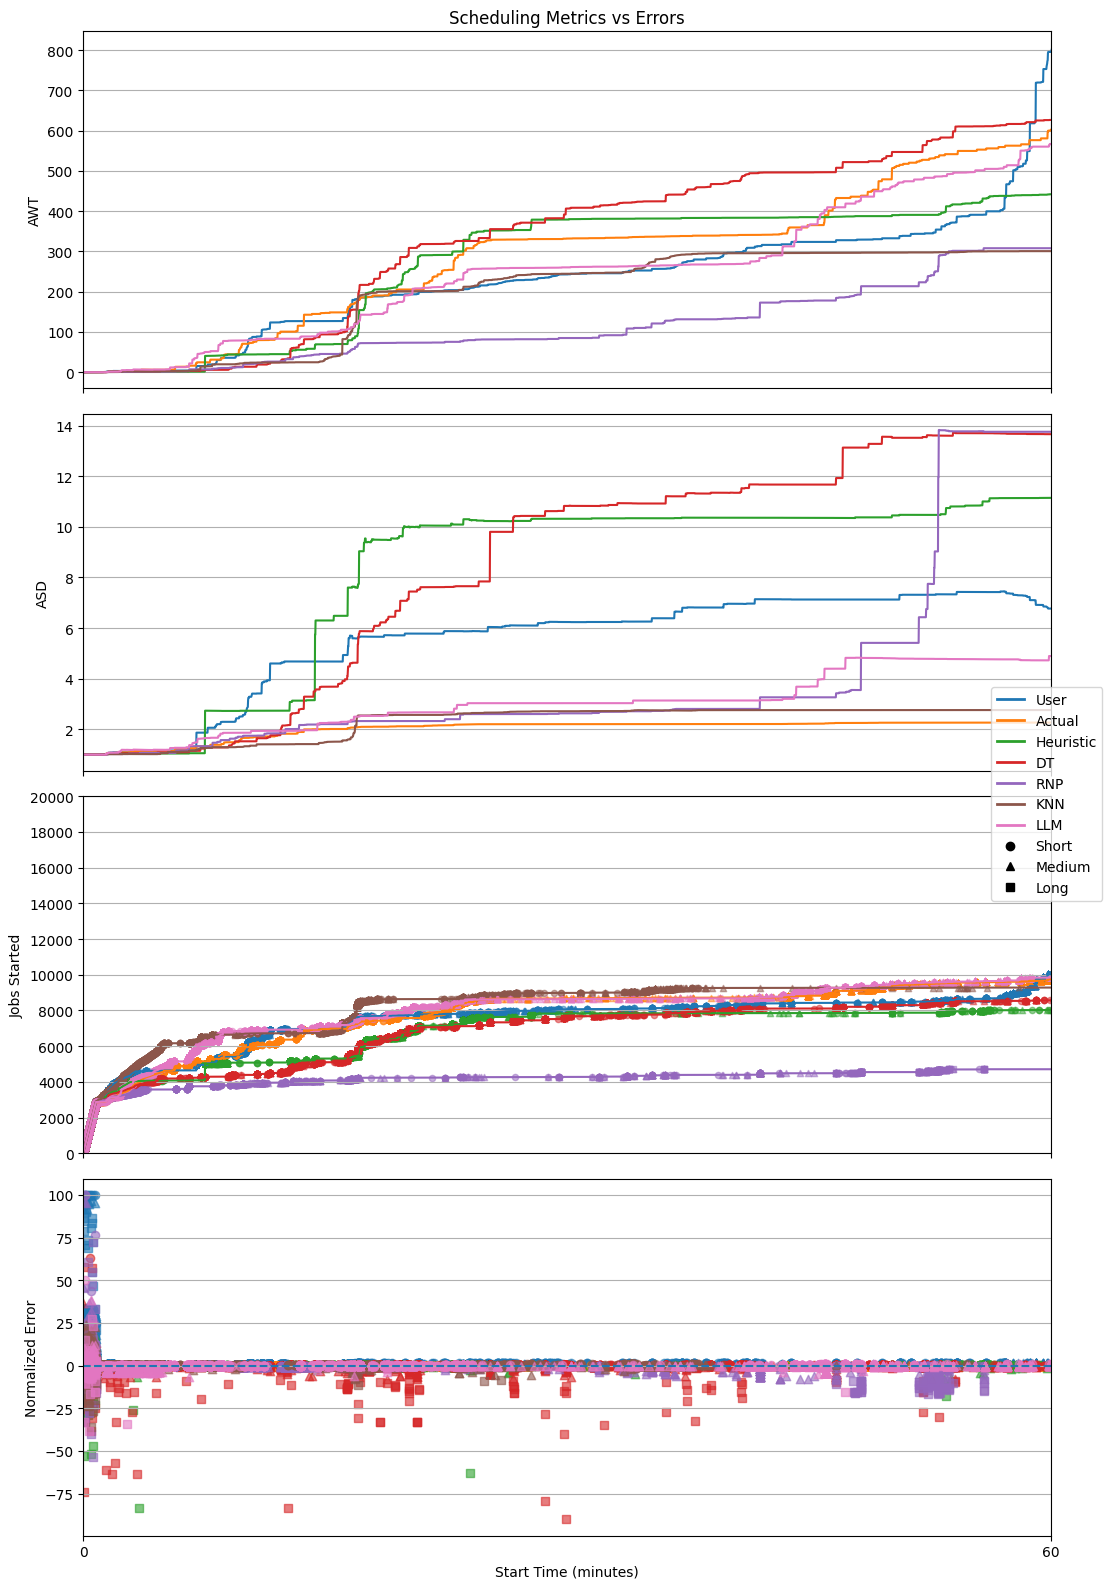

In [39]:
plot_metrics_with_errors(metrics, err_df, labels)

## Average System Utilization

In [40]:
print("User      =", metrics_user['average_utilization'])
print("Actual    =", metrics_actual['average_utilization'])
print("Heuristic =", metrics_heuristic['average_utilization'])
print("DT        =", metrics_dt['average_utilization'])
print("RNP       =", metrics_rnp['average_utilization'])
print("KNN       =", metrics_knn['average_utilization'])
print("LLM       =", metrics_llm['average_utilization'])

User      = 0.22307418225351372
Actual    = 0.22412808574794293
Heuristic = 0.22275519374886815
DT        = 0.22201645155145783
RNP       = 0.22227231860498348
KNN       = 0.22300202325115365
LLM       = 0.2241280857479429


# Heavy 5

## System Metrics Computation

In [20]:
# =========================================================
# LOAD WORKLOAD
# =========================================================

workload_df = pd.read_csv(
    'workloads/fdata/fdata_18k_5.swf',
    header=None,
    sep='\t'
)
workload_df.columns = workload_column_names
workload_df = workload_df.rename(columns={
    "Job Number": "job_id",
    "Submit Time": "submit_time"
})


# =========================================================
# ACTUAL
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_5/fdata_18k_5_SJF_Oracle.swf'
exec_df = load_swf(filepath, sim_start_time)

df_oracle = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_oracle = df_oracle.sort_values("start_time").reset_index(drop=True)
df_oracle = df_oracle[column_names]

err_df_actual = df_oracle.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_actual = assign_job_classes(err_df_actual)
err_df_actual = err_df_actual.rename(columns={"start_time": "st_actual"})
err_df_actual["err_actual"] = 0
err_df_actual = err_df_actual[["job_id", "duration_class", "size_class", "st_actual", "err_actual"]]

metrics_actual = compute_system_metrics(df_oracle, err_df_actual)

# sa_metrics_actual = compute_ordering_metrics(df_oracle, predictions, pred_col="gt_runtime")


# =========================================================
# USER
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_5/fdata_18k_5_SJF_User.swf'
exec_df = load_swf(filepath, sim_start_time)

df_user = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_user = df_user.sort_values("start_time").reset_index(drop=True)
df_user = df_user[column_names]

err_df_user = df_user.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_user = assign_job_classes(err_df_user)
err_df_user = err_df_user.rename(columns={"start_time": "st_user"})
err_df_user = err_df_user[["job_id", "duration_class", "size_class", "st_user", "err_user"]]

metrics_user = compute_system_metrics(df_user, err_df_user)

sa_metrics_user = compute_ordering_metrics(df_user, predictions, pred_col="pred_runtime_user")


# =========================================================
# HEURISTIC
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_5/fdata_18k_5_SJF_H.swf'
exec_df = load_swf(filepath, sim_start_time)

df_heuristic = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_heuristic = df_heuristic.sort_values("start_time").reset_index(drop=True)
df_heuristic = df_heuristic[column_names]

err_df_heuristic = df_heuristic.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_heuristic = assign_job_classes(err_df_heuristic)
err_df_heuristic = err_df_heuristic.rename(columns={"start_time": "st_heuristic"})
err_df_heuristic = err_df_heuristic[["job_id", "duration_class", "size_class", "st_heuristic", "err_heuristic"]]

metrics_heuristic = compute_system_metrics(df_heuristic, err_df_heuristic)

sa_metrics_heuristic = compute_ordering_metrics(df_heuristic, predictions, pred_col="pred_runtime_heuristic")


# =========================================================
# DT
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_5/fdata_18k_5_SJF_DT.swf'
exec_df = load_swf(filepath, sim_start_time)


df_dt = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_dt = df_dt.sort_values("start_time").reset_index(drop=True)
df_dt = df_dt[column_names]

err_df_dt = df_dt.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_dt = assign_job_classes(err_df_dt)
err_df_dt = err_df_dt.rename(columns={"start_time": "st_dt"})
err_df_dt = err_df_dt[["job_id", "duration_class", "size_class", "st_dt", "err_dt"]]

metrics_dt = compute_system_metrics(df_dt, err_df_dt)

sa_metrics_dt = compute_ordering_metrics(df_dt, predictions, pred_col="pred_runtime_dt")


# =========================================================
# RNP
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_5/fdata_18k_5_SJF_RNP.swf'
exec_df = load_swf(filepath, sim_start_time)

df_rnp = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_rnp = df_rnp.sort_values("start_time").reset_index(drop=True)
df_rnp = df_rnp[column_names]

err_df_rnp = df_rnp.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_rnp = assign_job_classes(err_df_rnp)
err_df_rnp = err_df_rnp.rename(columns={"start_time": "st_rnp"})
err_df_rnp = err_df_rnp[["job_id", "duration_class", "size_class", "st_rnp", "err_rnp"]]

metrics_rnp = compute_system_metrics(df_rnp, err_df_rnp)

sa_metrics_rnp = compute_ordering_metrics(df_rnp, predictions, pred_col="pred_runtime_rnp")


# =========================================================
# KNN
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_5/fdata_18k_5_SJF_KNN.swf'
exec_df = load_swf(filepath, sim_start_time)

df_knn = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_knn = df_knn.sort_values("start_time").reset_index(drop=True)
df_knn = df_knn[column_names]

err_df_knn = df_knn.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_knn = assign_job_classes(err_df_knn)
err_df_knn = err_df_knn.rename(columns={"start_time": "st_knn"})
err_df_knn = err_df_knn[["job_id", "duration_class", "size_class", "st_knn", "err_knn"]]

metrics_knn = compute_system_metrics(df_knn, err_df_knn)

sa_metrics_knn = compute_ordering_metrics(df_knn, predictions, pred_col="pred_runtime_knn")


# =========================================================
# LLM
# =========================================================

filepath = 'queues/fdata/18000x158976/heavy_5/fdata_18k_5_SJF_LLM.swf'
exec_df = load_swf(filepath, sim_start_time)

df_llm = exec_df.merge(
    workload_df[["job_id", "submit_time"]],
    on="job_id",
    how="left"
)
df_llm = df_llm.sort_values("start_time").reset_index(drop=True)
df_llm = df_llm[column_names]

err_df_llm = df_llm.merge(
    errors_df,
    on="job_id",
    how="left"
)
err_df_llm = assign_job_classes(err_df_llm)
err_df_llm = err_df_llm.rename(columns={"start_time": "st_llm"})
err_df_llm = err_df_llm[["job_id", "duration_class", "size_class", "st_llm", "err_llm"]]

metrics_llm = compute_system_metrics(df_llm, err_df_llm)

sa_metrics_llm = compute_ordering_metrics(df_llm, predictions, pred_col="pred_runtime_llm")

In [21]:
print(f'"OD_AWT_F5": [{sa_metrics_user["OD_AWT"]}, 0, {sa_metrics_heuristic["OD_AWT"]}, {sa_metrics_dt["OD_AWT"]}, {sa_metrics_rnp["OD_AWT"]}, {sa_metrics_knn["OD_AWT"]}, {sa_metrics_llm["OD_AWT"]}],') 
print(f'"OD_ASD_F5": [{sa_metrics_user["OD_ASD"]}, 0, {sa_metrics_heuristic["OD_ASD"]}, {sa_metrics_dt["OD_ASD"]}, {sa_metrics_rnp["OD_ASD"]}, {sa_metrics_knn["OD_ASD"]}, {sa_metrics_llm["OD_ASD"]}]')

"OD_AWT_F5": [301858160033.964, 0, 403409601682.4585, 699519327224.1111, 1047251423948.3341, 244555216515.20038, 61256876741.91601],
"OD_ASD_F5": [2360844492.4526463, 0, 2299522504.6009984, 1196179463.6419253, 5253294079.699621, 630193907.542351, 169829232.4196639]


## Merge metrics and errors

In [42]:
metrics = [
    metrics_user,
    metrics_actual,
    metrics_heuristic,
    metrics_dt,
    metrics_rnp,
    metrics_knn,
    metrics_llm
]

labels = [
    "User",
    "Actual",
    "Heuristic",
    "DT",
    "RNP",
    "KNN",
    "LLM"
]

In [43]:
err_df = err_df_user.merge(
            err_df_actual[["job_id", "st_actual", "err_actual"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_heuristic[["job_id", "st_heuristic", "err_heuristic"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_dt[["job_id", "st_dt", "err_dt"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_rnp[["job_id", "st_rnp", "err_rnp"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_knn[["job_id", "st_knn", "err_knn"]],
            on="job_id",
            how="left"
)

err_df = err_df.merge(
            err_df_llm[["job_id", "st_llm", "err_llm"]],
            on="job_id",
            how="left"
)

## Plots

### System Utilization

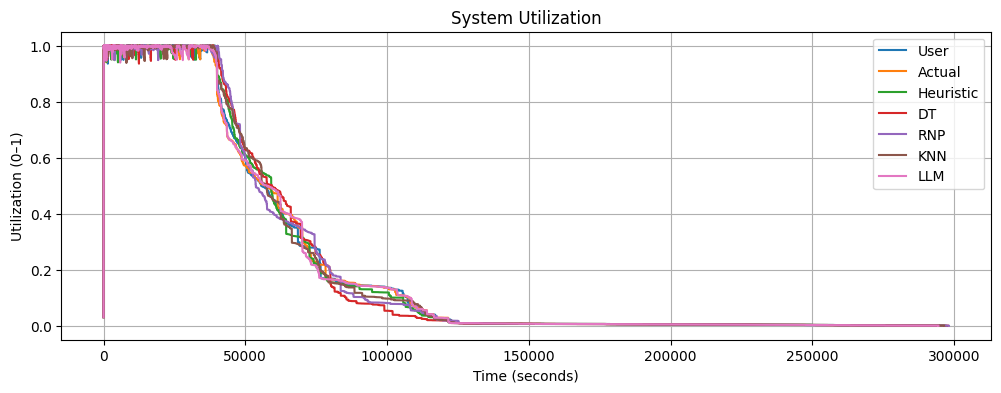

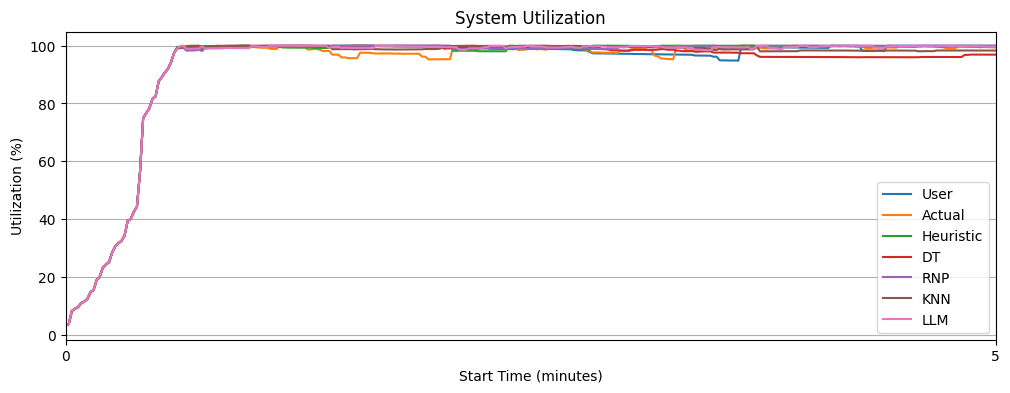

C:\Users\trap9\AppData\Local\Temp\ipykernel_606872\2120994538.py:34: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(0, max(ticks))


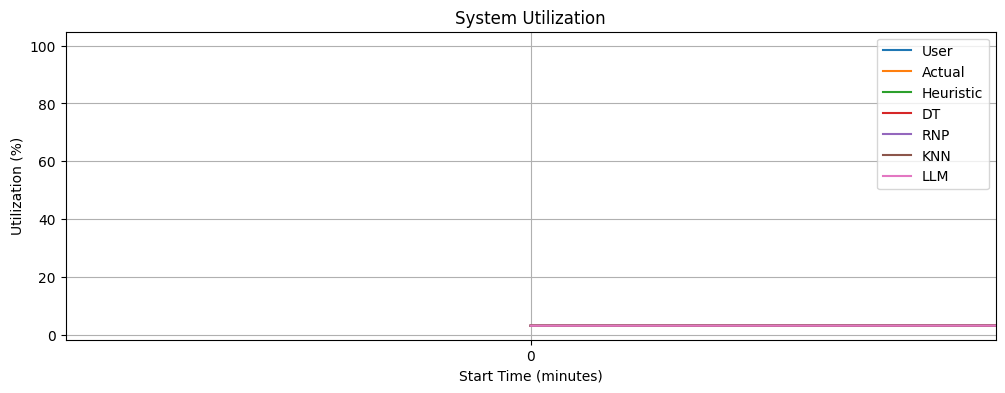

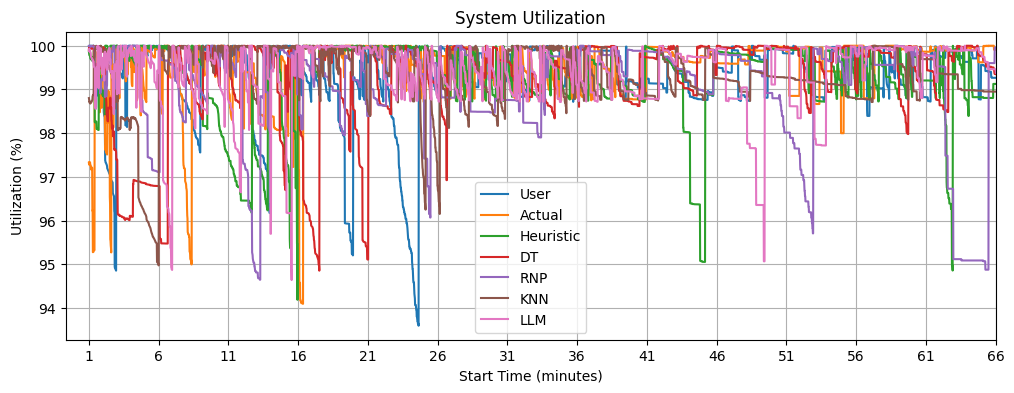

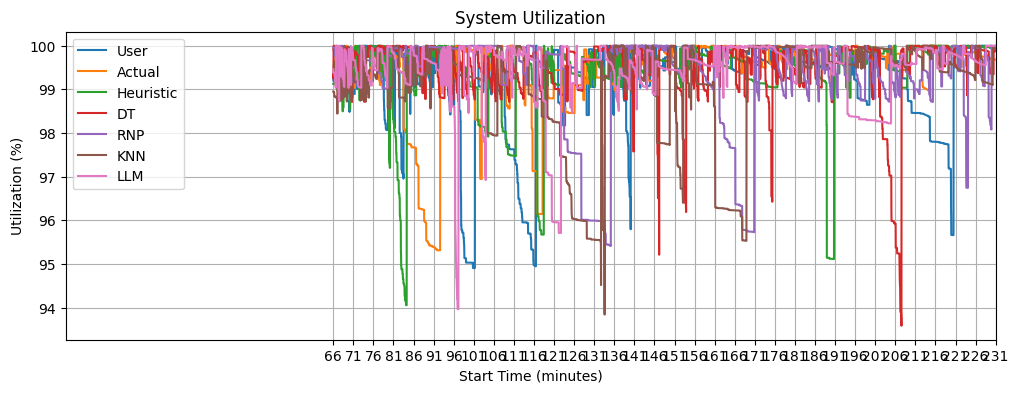

In [44]:
plot_metrics(metrics, labels)

plot_metrics_window(metrics, labels, 0, 301)

plot_metrics_window(metrics, labels, 0, 101)

plot_metrics_window(metrics, labels, 100, 4001)

plot_metrics_window(metrics, labels, 4000, 14001)

### System Metrics vs Prediction Error

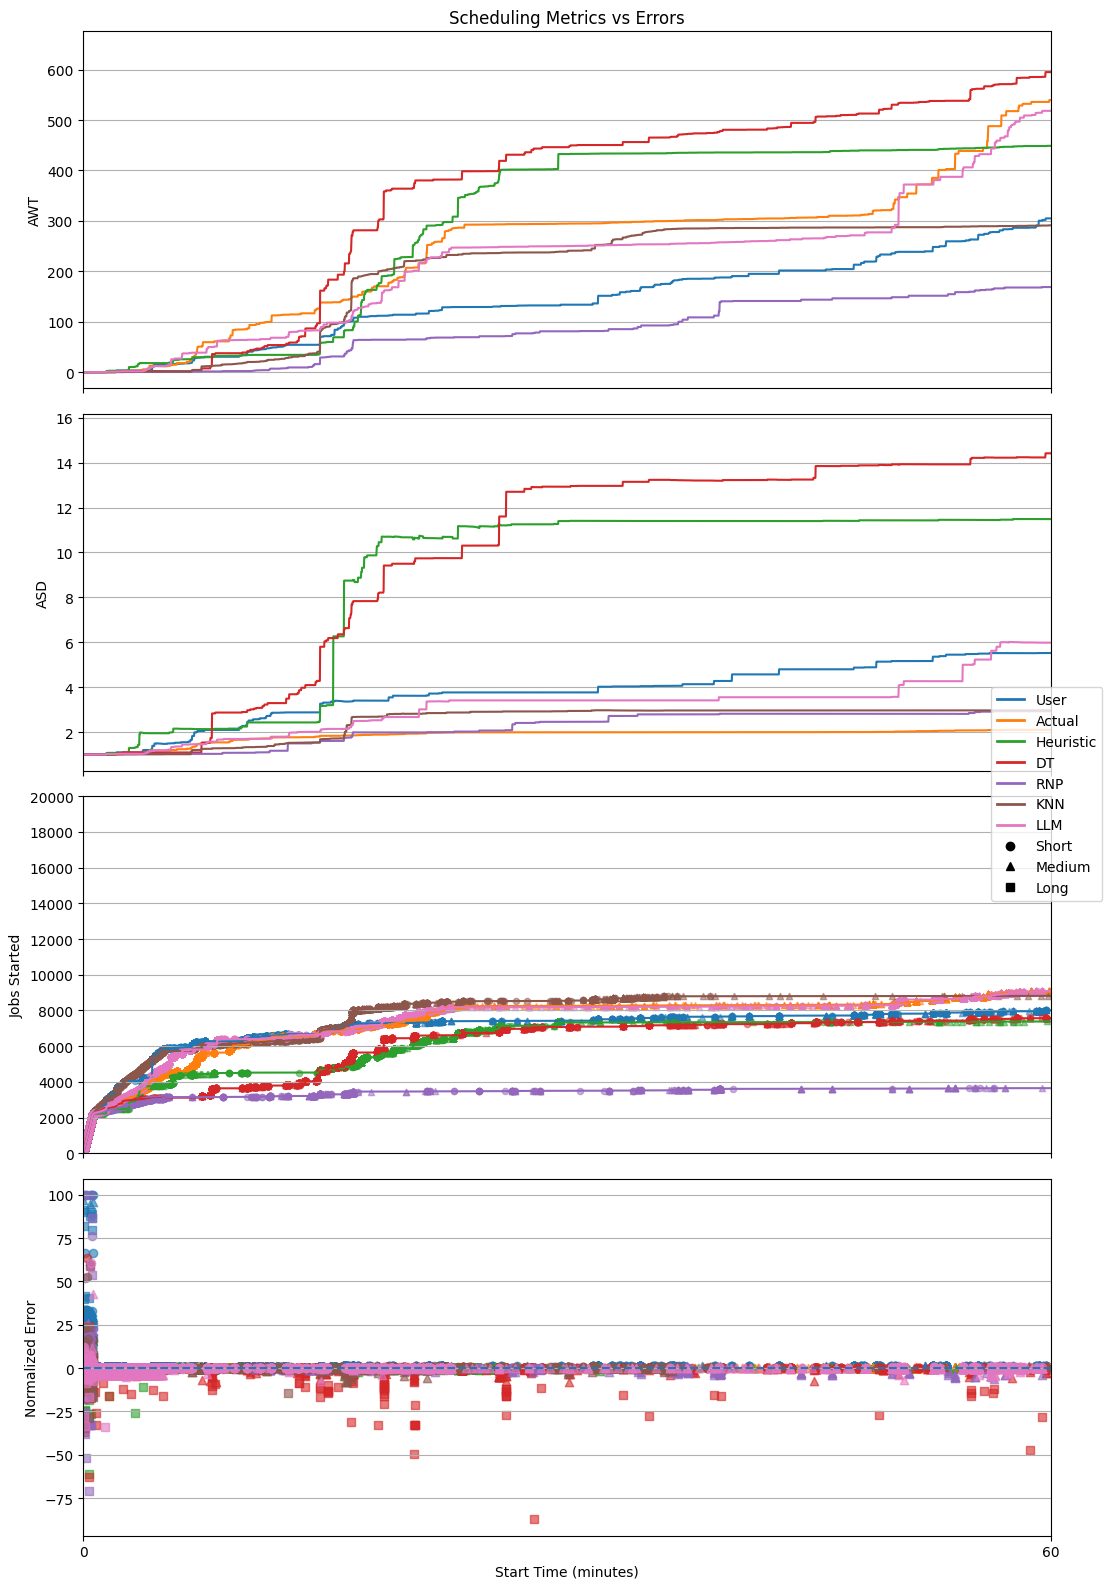

In [45]:
plot_metrics_with_errors(metrics, err_df, labels)

## Average System Utilization

In [46]:
print("User      =", metrics_user['average_utilization'])
print("Actual    =", metrics_actual['average_utilization'])
print("Heuristic =", metrics_heuristic['average_utilization'])
print("DT        =", metrics_dt['average_utilization'])
print("RNP       =", metrics_rnp['average_utilization'])
print("KNN       =", metrics_knn['average_utilization'])
print("LLM       =", metrics_llm['average_utilization'])

User      = 0.21302956462912953
Actual    = 0.2147840838756732
Heuristic = 0.213343949616958
DT        = 0.21250051177875684
RNP       = 0.21231453971825923
KNN       = 0.21354901400208487
LLM       = 0.21498608775050065
